# Bank Personal Loan Prediction

This project aims to predict whether a bank customer is likely to accept a personal loan offer. The goal is to help the bank improve campaign targeting, reduce unnecessary marketing costs, and increase conversion efficiency through data-driven decision-making.

## Problem Statement

The bank has observed low acceptance rates in its personal loan campaigns. Sending offers to all customers is inefficient and costly. To solve this, the project builds a classification model that predicts which customers are most likely to respond positively to a personal loan offer.

## Project Objective

The objective is to develop a machine learning model that can identify likely loan accepters based on customer demographics, financial characteristics, and existing banking relationships.

## Dataset Description

The dataset contains customer-level information such as age, income, family size, credit card spending, mortgage value, education, and banking account details. The target variable is Personal Loan, which indicates whether the customer accepted the loan offer (1) or not (0).

| Feature | Description |
|--------|-------------|
| `ID` | Unique Customer ID |
| `Age` | Age of the customer (in years) |
| `Experience` | Work experience (in years) |
| `Income` | Annual income (in $000) |
| `ZIP Code` | Residential ZIP code |
| `Family` | Number of family members |
| `CCAvg` | Avg. monthly credit card spend (in $000) |
| `Education` | Education level (1: Undergrad, 2: Graduate, 3: Advanced/Professional) |
| `Mortgage` | Value of mortgage (in $000) |
| `Securities Account` | Has securities account? (0: No, 1: Yes) |
| `CD Account` | Has certificate of deposit account? (0: No, 1: Yes) |
| `Online` | Uses internet banking? (0: No, 1: Yes) |
| `CreditCard` | Uses bank-issued credit card? (0: No, 1: Yes) |
| `Personal Loan` | **Target variable** – accepted personal loan? (0: No, 1: Yes) |

## 1. Import Libraries

This section imports the libraries used for data handling, visualization, preprocessing, modelling, and evaluation.

In [7868]:
# Data handling
import math
import numpy as np
import pandas as pd
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

# Statistical modelling
import statsmodels.api as sm

# Feature selection
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# ZIP code handling
import zipcodes as zcode

# Display settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Data Loading

The dataset is loaded into a pandas DataFrame for initial inspection.

In [7869]:
DATA_PATH = Path("../data/raw/Bank_Personal_Loan_Modelling.csv")

data = pd.read_csv(DATA_PATH)

## 3. Data Overview

This section provides an initial understanding of the dataset, including its structure, key statistics, data quality, and feature patterns before preprocessing.

### 3.1 Dataset Preview

The first few rows are displayed to check the dataset structure and verify that the data has loaded correctly.


In [7870]:
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.00,2,0,0,0,0,0,1


### 3.2 Dataset Dimensions 
This step verifies the number of observations and features.

In [7871]:
data.shape

(5000, 14)

### 3.3 Dataset Structure and Data Types 
We inspect column names, data types, and non-null counts to identify potential type issues or missing values.

In [7872]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


### 3.4 Summary Statistics (Numerical Features) 
Descriptive statistics help assess feature distributions, scale differences, and potential outliers.

In [7873]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.00,2500.50,1443.52,1.00,1250.75,2500.50,3750.25,5000.00
Age,5000.00,45.34,11.46,23.00,35.00,45.00,55.00,67.00
Experience,5000.00,20.10,11.47,-3.00,10.00,20.00,30.00,43.00
Income,5000.00,73.77,46.03,8.00,39.00,64.00,98.00,224.00
ZIP Code,5000.00,93152.50,2121.85,9307.00,91911.00,93437.00,94608.00,96651.00
Family,5000.00,2.40,1.15,1.00,1.00,2.00,3.00,4.00
CCAvg,5000.00,1.94,1.75,0.00,0.70,1.50,2.50,10.00
Education,5000.00,1.88,0.84,1.00,1.00,2.00,3.00,3.00
Mortgage,5000.00,56.50,101.71,0.00,0.00,0.00,101.00,635.00
Personal Loan,5000.00,0.10,0.29,0.00,0.00,0.00,0.00,1.00


### 3.5 Missing Values Analysis 
Checking for missing values helps assess data completeness.

In [7874]:
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

### 3.6 Duplicate Records 
Duplicate rows can negatively impact model performance and must be identified.

In [7875]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


### 3.7 Class Balance

Distribution of the target variable to determine whether the dataset is balanced or imbalanced.

In [7876]:
loan_dist = data["Personal Loan"].value_counts(normalize=True).mul(100).round(2)
print(loan_dist)

Personal Loan
0   90.40
1    9.60
Name: proportion, dtype: float64


### 3.8 Number of Unique Values in Each Column
Analyzes the number of distinct values in each column to understand feature variability and data types.


In [7877]:
# Unique values per column
print("\nUnique Values per Column:\n")
print(data.nunique())


Unique Values per Column:

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal Loan            2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
dtype: int64


### 3.9 Column Names in the Dataset
Lists all column names to provide a clear overview of the dataset’s structure and features.

In [7878]:
print("\nColumn Names:\n")
print(data.columns.tolist())


Column Names:

['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


### 3.10 Correlation Analysis 
We evaluate linear relationships between numerical variables using a Pearson correlation matrix.

In [7879]:
numeric_col = data.select_dtypes(include=np.number)
numeric_col.corr(method="pearson")

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.00,-0.01,-0.01,-0.02,0.01,-0.02,-0.02,0.02,-0.01,-0.02,-0.02,-0.01,-0.00,0.02
Age,-0.01,1.00,0.99,-0.06,-0.03,-0.05,-0.05,0.04,-0.01,-0.01,-0.00,0.01,0.01,0.01
Experience,-0.01,0.99,1.00,-0.05,-0.03,-0.05,-0.05,0.01,-0.01,-0.01,-0.00,0.01,0.01,0.01
Income,-0.02,-0.06,-0.05,1.00,-0.02,-0.16,0.65,-0.19,0.21,0.50,-0.00,0.17,0.01,-0.00
ZIP Code,0.01,-0.03,-0.03,-0.02,1.00,0.01,-0.00,-0.02,0.01,0.00,0.00,0.02,0.02,0.01
Family,-0.02,-0.05,-0.05,-0.16,0.01,1.00,-0.11,0.06,-0.02,0.06,0.02,0.01,0.01,0.01
CCAvg,-0.02,-0.05,-0.05,0.65,-0.00,-0.11,1.00,-0.14,0.11,0.37,0.02,0.14,-0.00,-0.01
Education,0.02,0.04,0.01,-0.19,-0.02,0.06,-0.14,1.00,-0.03,0.14,-0.01,0.01,-0.02,-0.01
Mortgage,-0.01,-0.01,-0.01,0.21,0.01,-0.02,0.11,-0.03,1.00,0.14,-0.01,0.09,-0.01,-0.01
Personal Loan,-0.02,-0.01,-0.01,0.50,0.00,0.06,0.37,0.14,0.14,1.00,0.02,0.32,0.01,0.00


### 3.11 Education vs Personal Loan

This section shows how personal loan acceptance varies across education levels using counts and percentages.

In [7880]:
# Crosstab to get counts of PersonalLoan by Education
edu_count = pd.crosstab(data['Education'], data['Personal Loan'])

# Crosstab to get percentage of PersonalLoan by Education 
edu_pct = pd.crosstab(
    data['Education'],
    data['Personal Loan'],
    normalize='index'
) * 100


print("Education vs Personal Loan (Count)")
print(edu_count)

print("\nEducation vs Personal Loan (Percentage)")
print(edu_pct.round(2))

Education vs Personal Loan (Count)
Personal Loan     0    1
Education               
1              2003   93
2              1221  182
3              1296  205

Education vs Personal Loan (Percentage)
Personal Loan     0     1
Education                
1             95.56  4.44
2             87.03 12.97
3             86.34 13.66


### 3.12 Family Size vs Personal Loan

This section shows how personal loan acceptance varies across family sizes using counts and percentages. 


In [7881]:
# Crosstab to get counts of PersonalLoan by Family size
family_count = pd.crosstab(data['Family'], data['Personal Loan'])

# Crosstab to get percentage of PersonalLoan by Family size 
family_pct = pd.crosstab(
    data['Family'],
    data['Personal Loan'],
    normalize='index'
) * 100

print("\nFamily vs Personal Loan (Count)")
print(family_count)

print("\nFamily vs Personal Loan (Percentage)")
print(family_pct.round(2))



Family vs Personal Loan (Count)
Personal Loan     0    1
Family                  
1              1365  107
2              1190  106
3               877  133
4              1088  134

Family vs Personal Loan (Percentage)
Personal Loan     0     1
Family                   
1             92.73  7.27
2             91.82  8.18
3             86.83 13.17
4             89.03 10.97


## 4. Feature Distributions 
The distributions of numerical and categorical features provide an overview of customer characteristics in the dataset. 


### 4.1 Individual Numerical and Categorical Features
This section examines the distribution of individual numerical and categorical features. Understanding these distributions helps identify skewness, dominant categories, and potential patterns that may influence model performance.

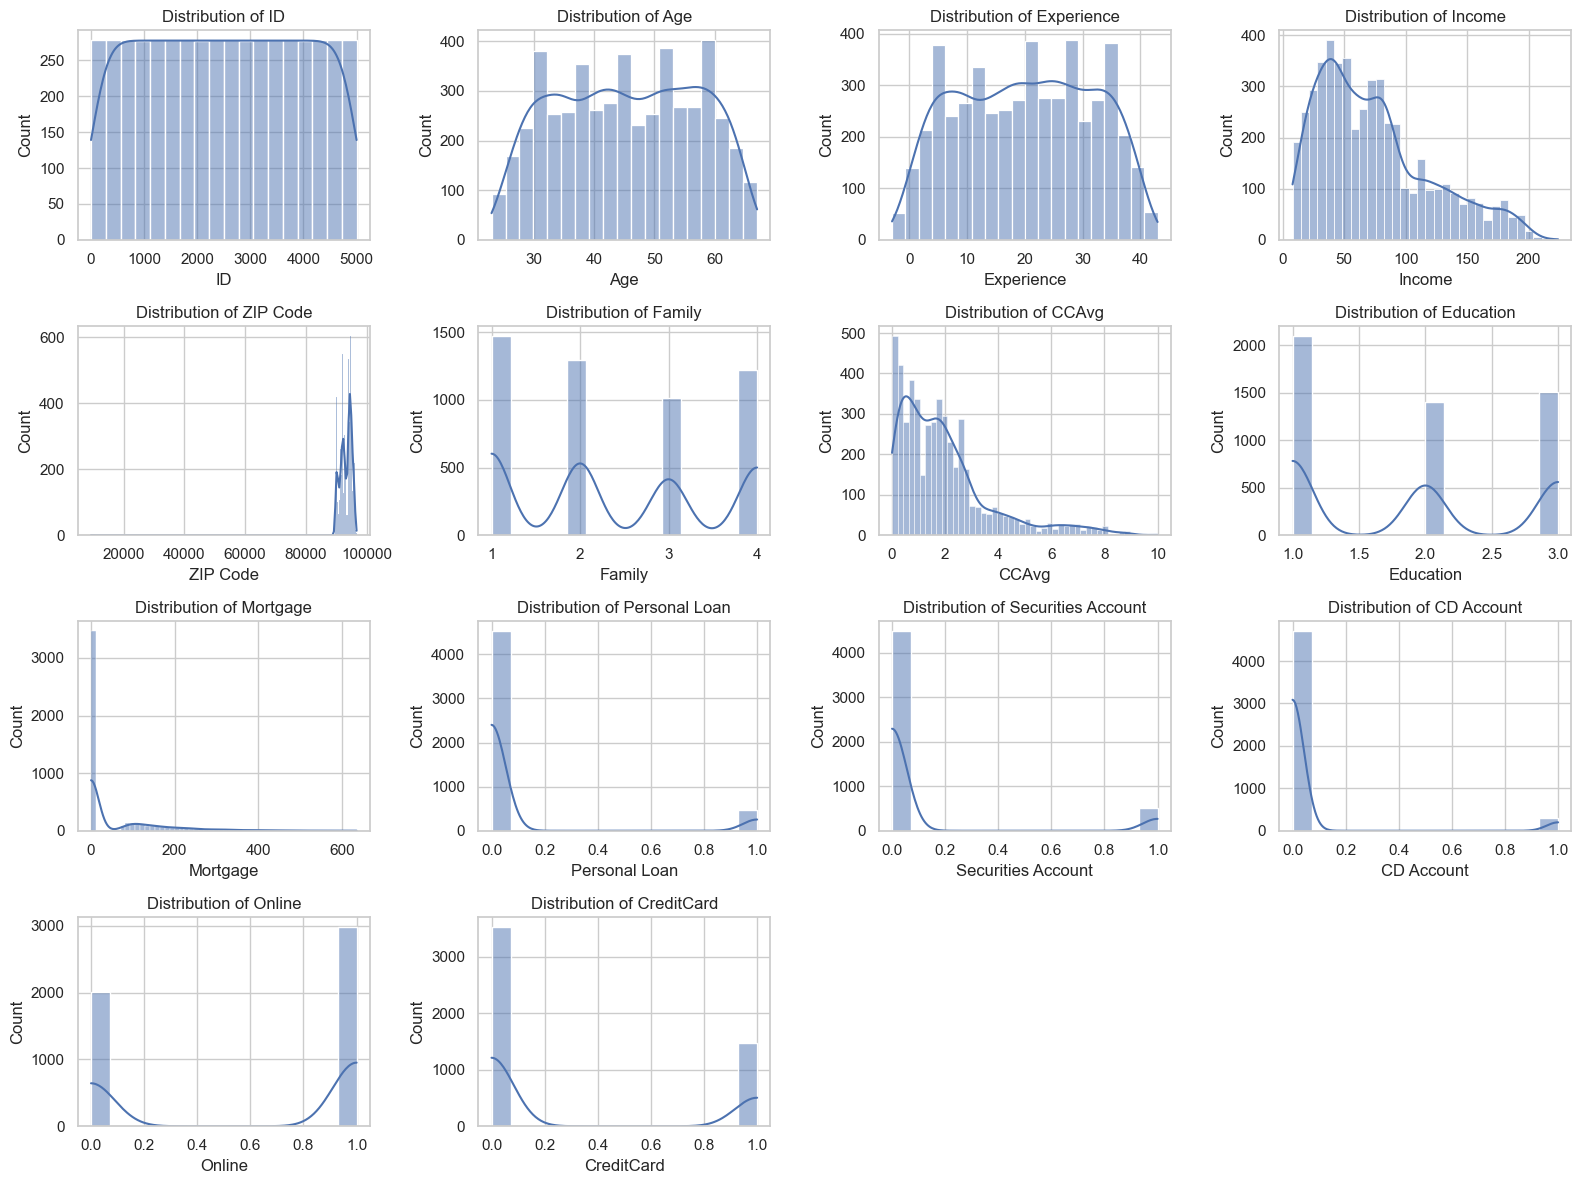

In [7882]:
# Numerical feature distributions
numeric_cols = data.select_dtypes(include="number").columns.to_list()

plt.figure(figsize=(16, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(data=data, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


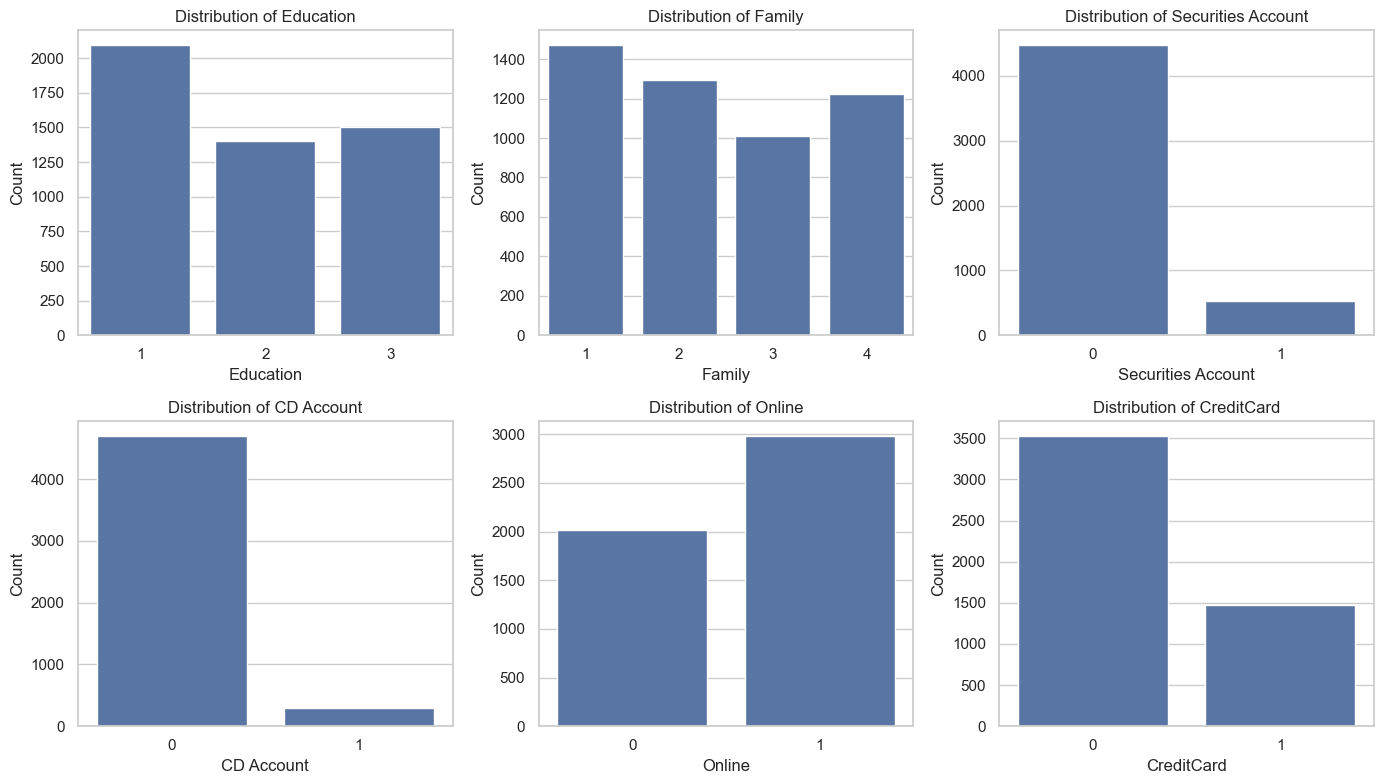

In [7883]:
# Categorical feature distributions
cat_cols = ["Education", "Family", "Securities Account", 
            "CD Account", "Online", "CreditCard"]

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(14, 8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=data, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

### 4.2 Target Variable Distribution
This chart shows the distribution of the target variable, **Personal Loan**, to understand whether the classes are balanced. Checking class balance is important because an imbalanced target can affect model evaluation and model behaviour.

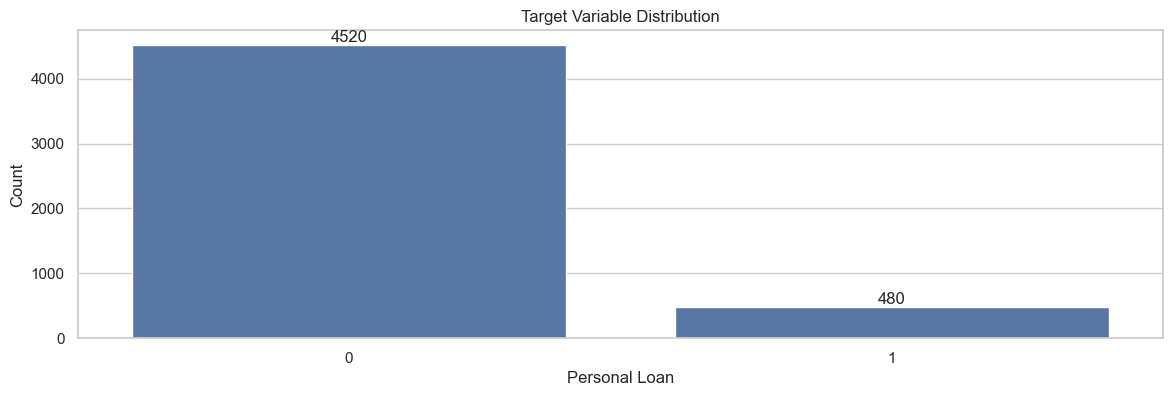

In [7884]:
ax = sns.countplot(data=data, x="Personal Loan")

plt.title("Target Variable Distribution")
plt.xlabel("Personal Loan")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

### 4.3 Correlation Heatmap
This heatmap shows correlation analysis helps identify linear relationships between variables and highlights features that may be strongly associated with the target variable.

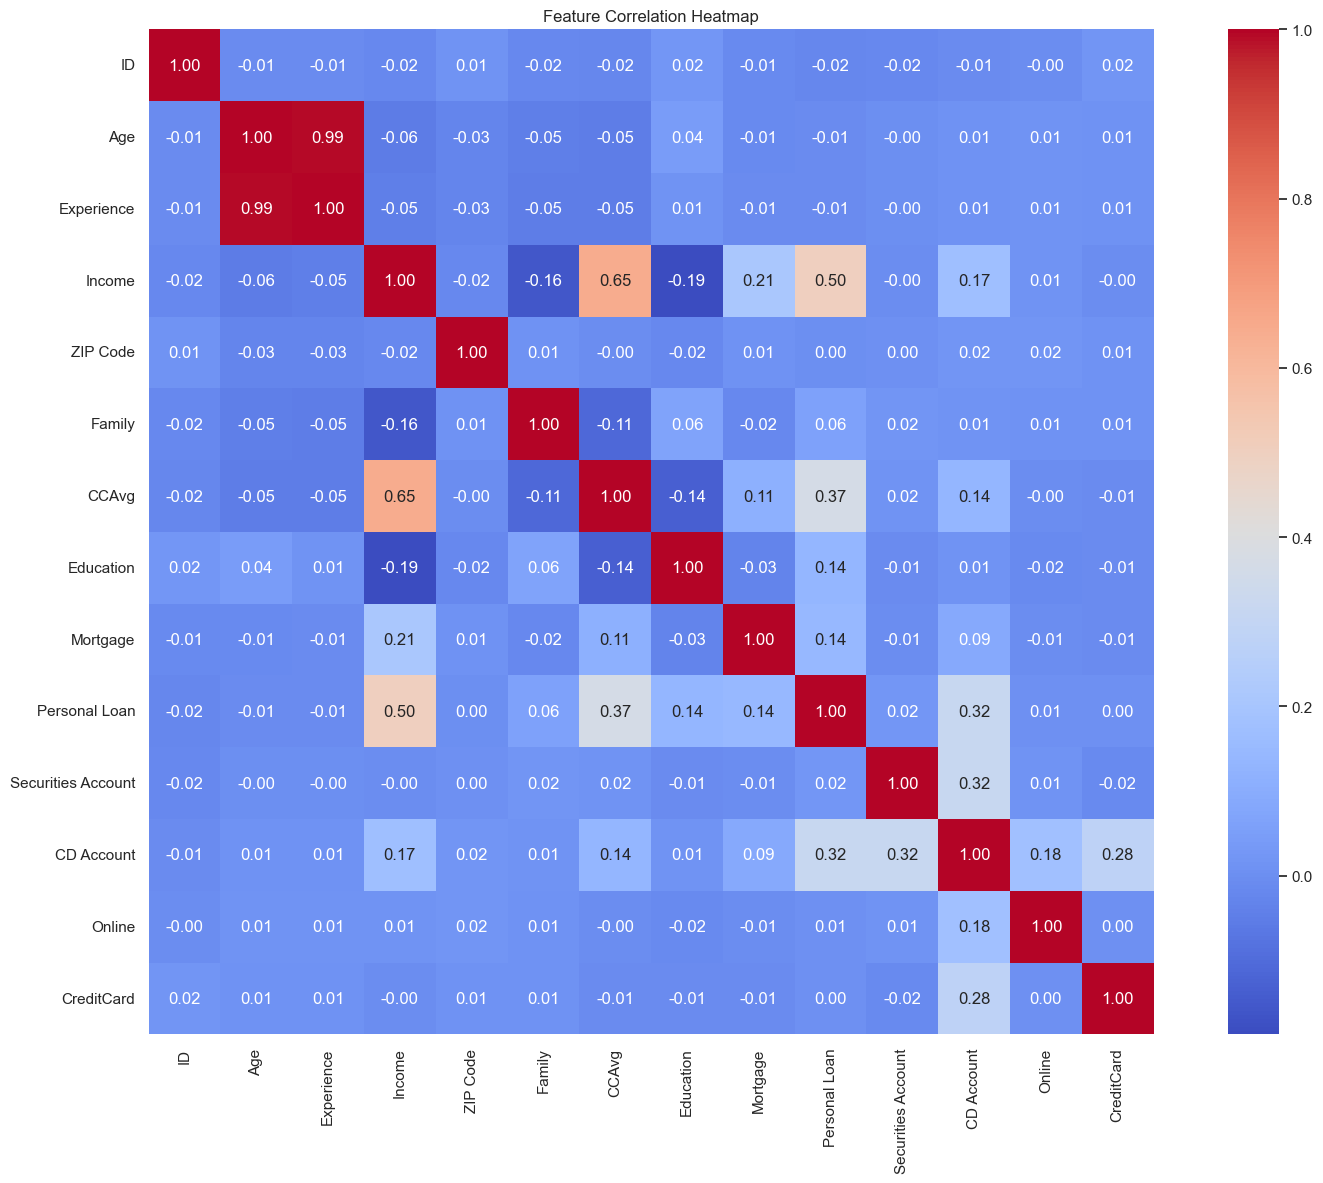

In [7885]:
# Correlation matrix for numerical features
plt.figure(figsize=(16, 12))
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", square=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

> **Interpretation:**  The visual analysis suggests that both numerical and categorical features contain useful signals for predicting personal loan acceptance.

## 5. Feature Engineering

This section prepares the dataset for modelling by removing non-predictive fields, standardising column names, and exploring ZIP code values for possible geographic feature engineering.

### 5.1 Drop ID Column

The `ID` column is removed because it is a unique identifier and does not provide predictive value.


In [7886]:
data.drop({'ID'}, axis=1,inplace=True)

### 5.2 Rename Columns

Column names are simplified for clarity and consistency.

In [7887]:
data.rename(columns={
    "ZIP Code": "ZIPCode",
    "Personal Loan": "PersonalLoan",
    "Securities Account": "SecuritiesAccount",
    "CD Account": "CDAccount"
}, inplace=True)

### 5.3 Extract Unique ZIP Codes

Unique ZIP codes are extracted to explore whether geographic information can be used for feature engineering.

In [7888]:

list_zipcode = data["ZIPCode"].unique()


### 5.4 Map ZIP Codes to Counties

ZIP codes are converted into county-level information to create a broader and more interpretable geographic feature for modelling.


In [7889]:
list_zipcode = data["ZIPCode"].unique()

# Create a dictionary to map each ZIP code to its county
dict_zip = {}

for zipcode in list_zipcode:
    zipcode_str = str(zipcode)
    match = zcode.matching(zipcode_str)
    
    if len(match) == 1:
        county = match[0].get("county")
    else:
        county = zipcode_str
        
    dict_zip[zipcode] = county

### 5.5 Add/Correct ZIP → County Mappings
Manually add or fix ZIP code to county mappings to handle missing entries.


In [7890]:
dict_zip.update({92717:'Orange County'})
dict_zip.update({92634:'Orange County'})

### 5.6 Create County Feature
Map ZIP codes to counties using the previously defined `dict_zip` dictionary to add a new location-based feature for modeling.


In [7891]:
data['County'] = data['ZIPCode'].map(dict_zip)
data.head(5)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County
0,25,1,49,91107,4,1.60,1,0,0,1,0,0,0,Los Angeles County
1,45,19,34,90089,3,1.50,1,0,0,1,0,0,0,Los Angeles County
2,39,15,11,94720,1,1.00,1,0,0,0,0,0,0,Alameda County
3,35,9,100,94112,1,2.70,2,0,0,0,0,0,0,San Francisco County
4,35,8,45,91330,4,1.00,2,0,0,0,0,0,1,Los Angeles County


### 5.7 Explore County Feature
Check the number of unique counties, value distribution, and overall dataset info to ensure the feature was created correctly.


In [7892]:
# Number of unique counties
print("Number of unique counties:", data['County'].nunique())

# Frequency of each county
print("County value counts:\n", data['County'].value_counts())

# Dataset info including the new 'County' column
data.info()


Number of unique counties: 40
County value counts:
 County
Los Angeles County        1095
San Diego County           568
Santa Clara County         563
Alameda County             500
Orange County              366
San Francisco County       257
San Mateo County           204
Sacramento County          184
Santa Barbara County       154
Yolo County                130
Monterey County            128
Ventura County             114
San Bernardino County      101
Contra Costa County         85
Santa Cruz County           68
Riverside County            56
Marin County                54
Kern County                 54
San Luis Obispo County      33
Solano County               33
Humboldt County             32
Sonoma County               28
Fresno County               26
Placer County               24
Butte County                19
Shasta County               18
El Dorado County            17
Stanislaus County           15
San Benito County           14
San Joaquin County          13
Mendocino C

### 5.8 Convert Categorical Variables

Relevant variables are converted to the `category` data type to improve consistency and prepare the dataset for later analysis and modelling.


In [7893]:
category_col = [
    "PersonalLoan",
    "SecuritiesAccount",
    "Family",
    "CDAccount",
    "Online",
    "CreditCard",
    "ZIPCode",
    "Education",
    "County"
]

data[category_col] = data[category_col].astype("category")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                5000 non-null   int64   
 1   Experience         5000 non-null   int64   
 2   Income             5000 non-null   int64   
 3   ZIPCode            5000 non-null   category
 4   Family             5000 non-null   category
 5   CCAvg              5000 non-null   float64 
 6   Education          5000 non-null   category
 7   Mortgage           5000 non-null   int64   
 8   PersonalLoan       5000 non-null   category
 9   SecuritiesAccount  5000 non-null   category
 10  CDAccount          5000 non-null   category
 11  Online             5000 non-null   category
 12  CreditCard         5000 non-null   category
 13  County             5000 non-null   category
dtypes: category(9), float64(1), int64(4)
memory usage: 266.4 KB


### 5.9 County-to-Region Mapping

This step groups individual counties into broader geographic regions to reduce categorical complexity, improve interpretability, and support more meaningful regional-level analysis and modeling.

In [7894]:
# Mapping detailed county names to broader geographic regions
county = {
    'Los Angeles County':'Los Angeles Region',
    'San Diego County':'Southern',
    'Santa Clara County':'Bay Area',
    'Alameda County':'Bay Area',
    'Orange County':'Southern',
    'Orange Country':'Southern',  
    'San Francisco County':'Bay Area',
    'San Mateo County':'Bay Area',
    'Sacramento County':'Central',
    'Santa Barbara County':'Southern',
    'Yolo County':'Central',
    'Monterey County':'Bay Area',            
    'Ventura County':'Southern',             
    'San Bernardino County':'Southern',       
    'Contra Costa County':'Bay Area',        
    'Santa Cruz County':'Bay Area',           
    'Riverside County':'Southern',            
    'Kern County':'Southern',                 
    'Marin County':'Bay Area',                
    'San Luis Obispo County':'Southern',     
    'Solano County':'Bay Area',              
    'Humboldt County':'Superior',            
    'Sonoma County':'Bay Area',                
    'Fresno County':'Central',               
    'Placer County':'Central',                
    'Butte County':'Superior',               
    'Shasta County':'Superior',                
    'El Dorado County':'Central',             
    'Stanislaus County':'Central',            
    'San Benito County':'Bay Area',          
    'San Joaquin County':'Central',           
    'Mendocino County':'Superior',             
    'Tuolumne County':'Central',                
    'Siskiyou County':'Superior',              
    'Trinity County':'Superior',                
    'Merced County':'Central',                  
    'Lake County':'Superior',                 
    'Napa County':'Bay Area',                   
    'Imperial County':'Southern',
    93077:'Southern',
    96651:'Bay Area'
}


### 5.10 Assign Region Labels to the Dataset
This step applies the county-to-region mapping to create a new `Regions` feature, enabling regional-level analysis and comparison across the dataset.

In [7895]:
# Create a new Regions column by mapping counties to broader regions
data['Regions'] = data['County'].map(county)

# Inspect unique region values
data['Regions'].unique()

array(['Los Angeles Region', 'Bay Area', 'Southern', 'Superior',
       'Central', nan], dtype=object)

### 5.11 Check Negative Values in Experience

This step identifies records with negative values in the `Experience` column, which are likely data entry errors and need to be reviewed before modelling.


In [7896]:
# Summary statistics for customers with negative experience values
negative_experience_stats = data[data["Experience"] < 0]["Age"].describe()
#print(negative_experience_stats)

# Inspect rows with negative experience values
negative_experience_rows = data[data["Experience"] < 0].sort_values(by="Experience", ascending=True)
negative_experience_rows.head(5)


,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Regions
2618,23,-3,55,92704,3,2.40,2,145,0,0,0,1,0,Orange County,Southern
4514,24,-3,41,91768,4,1.00,3,0,0,0,0,1,0,Los Angeles County,Los Angeles Region
4285,23,-3,149,93555,2,7.20,1,0,0,0,0,1,0,Kern County,Southern
3626,24,-3,28,90089,4,1.00,3,0,0,0,0,0,0,Los Angeles County,Los Angeles Region
889,24,-2,82,91103,2,1.60,3,0,0,0,0,1,1,Los Angeles County,Los Angeles Region


### 5.12 Impute Negative Experience Values
Replace negative values in the 'Experience' column with their absolute values to correct data entry errors.


In [7897]:
# Replace negative values with absolute values
data.loc[data['Experience'] < 0, 'Experience'] = np.abs(data['Experience'])

# Check descriptive statistics for ages where 'Experience' = 0
zero_experience_stats = data[data['Experience'] == 0]['Age'].describe()


### 5.13 Explore Categorical Variables
Print value counts for each categorical column to understand feature distributions and identify potential preprocessing needs.


In [7898]:
for column in category_col:
    print(f"Value counts for {column}:")
    print(data[column].value_counts())
    print('=' * 40)


Value counts for PersonalLoan:
PersonalLoan
0    4520
1     480
Name: count, dtype: int64
Value counts for SecuritiesAccount:
SecuritiesAccount
0    4478
1     522
Name: count, dtype: int64
Value counts for Family:
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64
Value counts for CDAccount:
CDAccount
0    4698
1     302
Name: count, dtype: int64
Value counts for Online:
Online
1    2984
0    2016
Name: count, dtype: int64
Value counts for CreditCard:
CreditCard
0    3530
1    1470
Name: count, dtype: int64
Value counts for ZIPCode:
ZIPCode
94720    169
94305    127
95616    116
90095     71
93106     57
        ... 
94598      1
91024      1
90813      1
90068      1
9307       1
Name: count, Length: 467, dtype: int64
Value counts for Education:
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64
Value counts for County:
County
Los Angeles County        1095
San Diego County           568
Santa Clara County         563
Alameda County             50

### 5.14 Create Age Bins
Categorize the 'Age' column into bins to create a categorical feature for grouped analysis and modeling.

In [7899]:
# Create age bins
data['Agebin'] = pd.cut(
    data['Age'], 
    bins=[0, 30, 40, 50, 60, 100], 
    labels=['18-30', '31-40', '41-50', '51-60', '61-100']
)

# Check the distribution of the new age bins
print(data['Agebin'].value_counts())

Agebin
51-60     1323
41-50     1270
31-40     1236
18-30      624
61-100     547
Name: count, dtype: int64


### 5.15 Create Income Groups
Categorize the 'Income' column into 'Lower', 'Middle', and 'Higher' groups to create a categorical feature for analysis and modeling.

In [7900]:
# Create income groups
data["Income_group"] = pd.cut(
    x=data['Income'], 
    bins=[0, 50, 140, 224], 
    labels=['Lower', 'Middle', 'Higher']
)

# Display dataset with new income group
data.head(2)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Regions,Agebin,Income_group
0,25,1,49,91107,4,1.60,1,0,0,1,0,0,0,Los Angeles County,Los Angeles Region,18-30,Lower
1,45,19,34,90089,3,1.50,1,0,0,1,0,0,0,Los Angeles County,Los Angeles Region,41-50,Lower


### 5.16 Create Spending Groups
Categorize the 'CCAvg' column into 'Low', 'Medium', and 'High' spending groups to create a categorical feature for analysis and modeling.

In [7901]:
# Create spending groups
data["Spending_group"] = pd.cut(
    x=data['CCAvg'], 
    bins=[0.0, 0.7, 2.5, 10.0], 
    labels=['Low', 'Medium', 'High'], 
    include_lowest=True
)

# Display dataset with new spending group
data.head(2)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Regions,Agebin,Income_group,Spending_group
0,25,1,49,91107,4,1.60,1,0,0,1,0,0,0,Los Angeles County,Los Angeles Region,18-30,Lower,Medium
1,45,19,34,90089,3,1.50,1,0,0,1,0,0,0,Los Angeles County,Los Angeles Region,41-50,Lower,Medium


### 5.17 Missing Value Check After Feature Engineering

This step checks for missing values in the dataset after feature engineering and removes any rows containing missing data to ensure a complete dataset for analysis and modeling.


In [7902]:

# Check for missing values
data.isnull().sum()

# Remove rows with missing values
data.dropna(inplace=True)


### 5.18 Crosstab Insights: Education, Family Size, and Income vs Personal Loan

This step filters the dataset to inspect customers aged 48 with 24 years of experience, sorted by income in descending order. It helps identify high-value customers or unusual patterns in income and personal loan uptake within this specific demographic group.


In [7903]:

filtered_df = (
    data
    # Filter dataset for customers aged 48 with 24 years of experience
    .loc[(data['Age'] == 48) & (data['Experience'] == 24)]  
    # Sort by Income in descending order
    .sort_values(by='Income', ascending=False) 
    .head(2)
)

filtered_df

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Regions,Agebin,Income_group,Spending_group
3896,48,24,224,93940,2,6.67,1,0,0,0,1,1,1,Monterey County,Bay Area,41-50,Higher,High
196,48,24,165,93407,1,5.00,1,0,0,0,0,0,1,San Luis Obispo County,Southern,41-50,Higher,High


## 6. Exploratory Data Analysis After Cleaning

This section explores the cleaned dataset to better understand the distribution of continuous variables, including their central tendency, spread, and potential outliers.

### 6.1 Distribution and Boxplot Function

The following function combines a boxplot and histogram to visualise the distribution of a continuous variable. It also highlights the mean, median, and mode to support interpretation.

In [7904]:
def dist_box(data):
    name = data.name.upper()
    
    fig, (ax_box, ax_dis) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=(14, 4)
    )
    
    mean = data.mean()
    median = data.median()
    mode = data.mode().tolist()[0]

    sns.set_theme(style="white")
    fig.suptitle(f"Distribution of {name}", fontsize=16, fontweight="bold")

    # Boxplot
    sns.boxplot(
        x=data,
        showmeans=True,
        orient="h",
        color="skyblue",
        ax=ax_box
    )
    ax_box.set(xlabel="")
    sns.despine(top=True, right=True, left=True)

    # Histogram
    sns.histplot(data, kde=False, color="slateblue", ax=ax_dis)
    ax_dis.axvline(mean, color="crimson", linestyle="--", linewidth=2, label=f"Mean: {mean:.2f}")
    ax_dis.axvline(median, color="seagreen", linestyle="-", linewidth=2, label=f"Median: {median:.2f}")
    ax_dis.axvline(mode, color="darkorange", linestyle="-.", linewidth=2, label=f"Mode: {mode:.2f}")

    ax_dis.legend()
    plt.tight_layout()
    plt.show()

### 6.2 Univariate Analysis of Quantitative Variables

This step visualises the distribution, spread, and potential outliers of key quantitative features using the `dist_box` function.


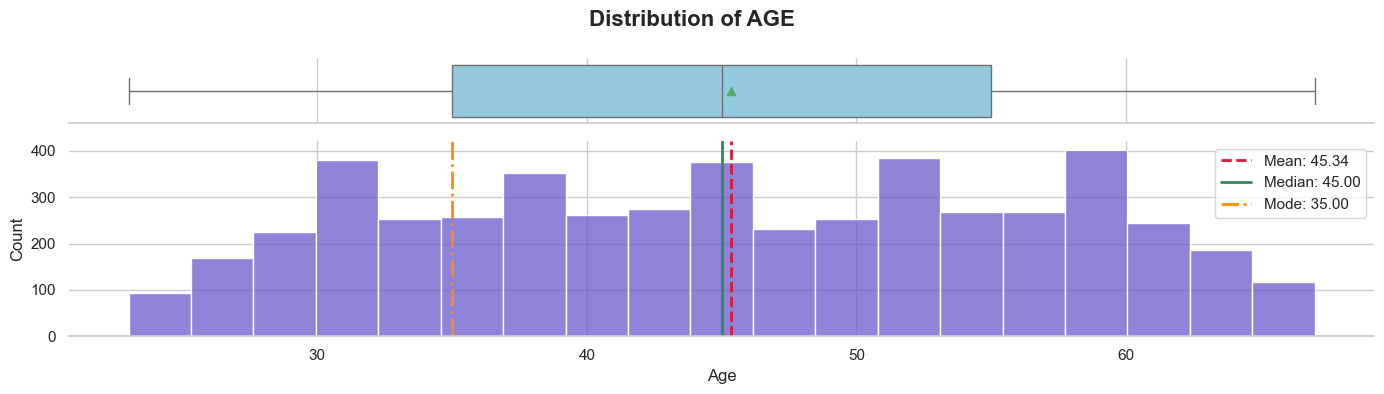

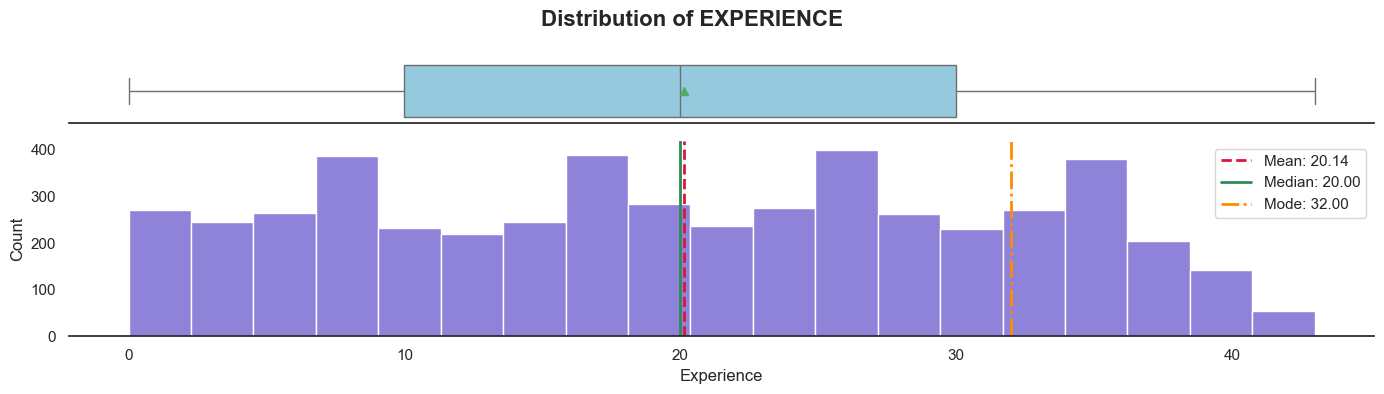

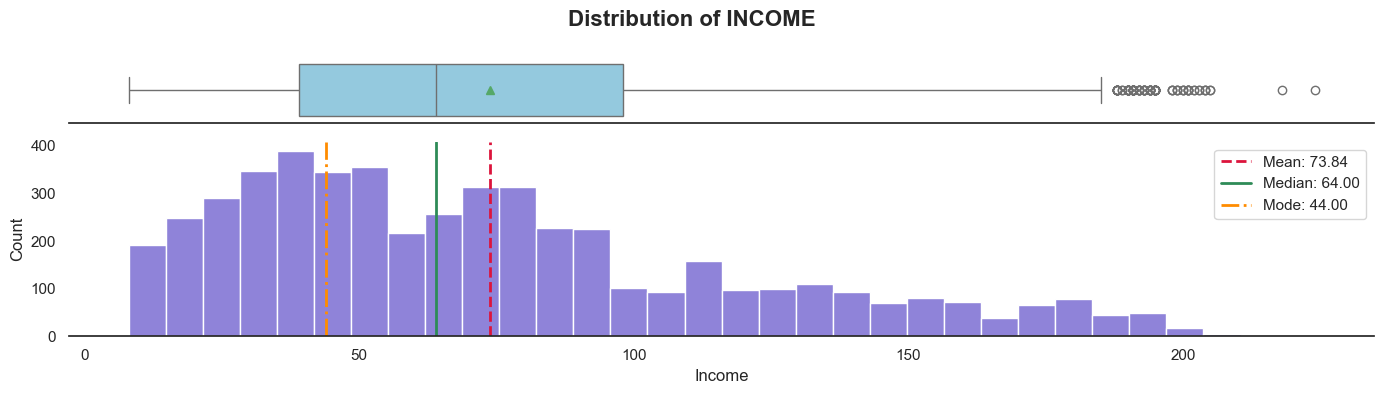

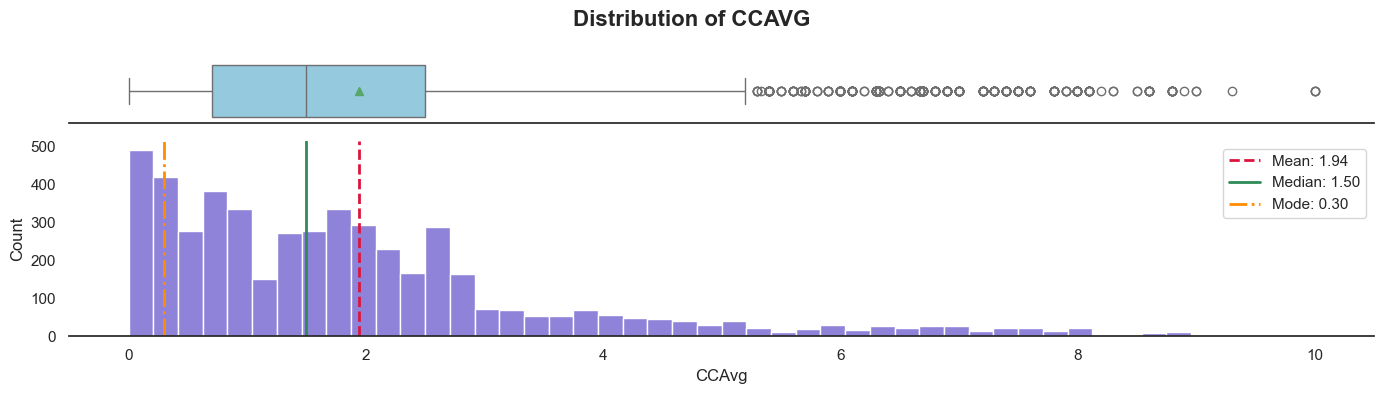

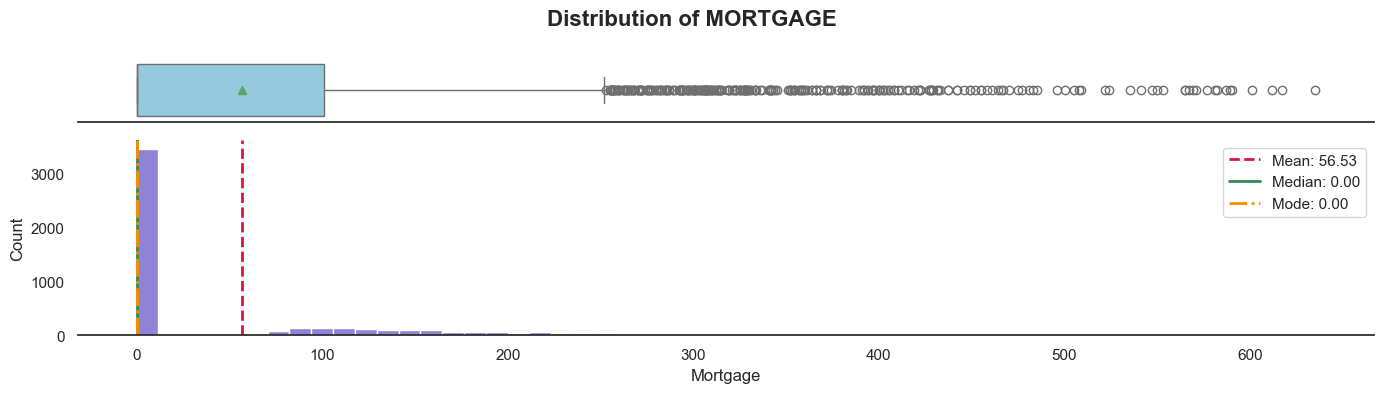

In [7905]:
# List of quantitative columns
list_col = ["Age", "Experience", "Income", "CCAvg", "Mortgage"]

# Visualise each quantitative feature
for col in list_col:
    dist_box(data[col])

### 6.3 Univariate Analysis of Categorical Variables

This step shows the frequency distribution of categorical variables to understand the composition of customer groups and engineered categories in the cleaned dataset.

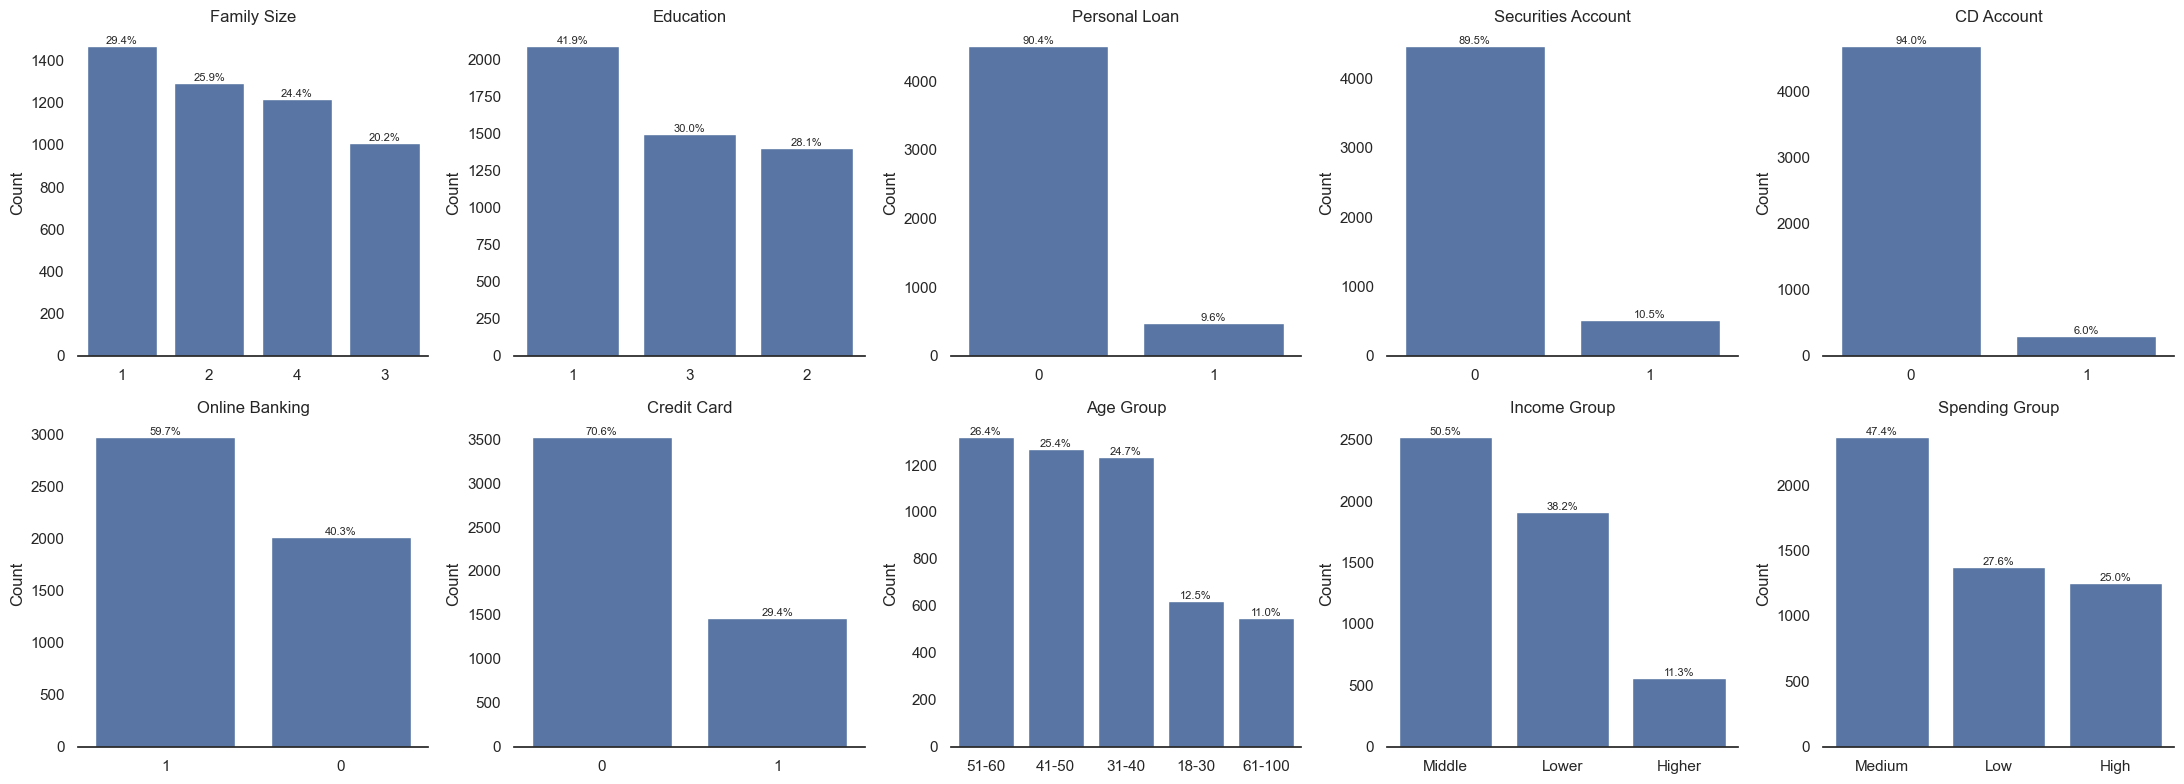

In [7906]:
# List of categorical columns
cat_columns = [
    "Family",
    "Education",
    "PersonalLoan",
    "SecuritiesAccount",
    "CDAccount",
    "Online",
    "CreditCard",
    "Agebin",
    "Income_group",
    "Spending_group"
]

# Titles for plots
title = [
    "Family Size",
    "Education",
    "Personal Loan",
    "Securities Account",
    "CD Account",
    "Online Banking",
    "Credit Card",
    "Age Group",
    "Income Group",
    "Spending Group"
]

n_cols = 5
n_rows = math.ceil(len(cat_columns) / n_cols)

plt.figure(figsize=(22, 4 * n_rows))

for i, variable in enumerate(cat_columns):
    plt.subplot(n_rows, n_cols, i + 1)

    order = data[variable].value_counts(ascending=False).index
    ax = sns.countplot(data=data, x=variable, order=order)
    sns.despine(top=True, right=True, left=True)

    for p in ax.patches:
        percentage = f"{100 * p.get_height() / len(data):.1f}%"
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        plt.annotate(percentage, (x, y), ha="center", va="bottom", fontsize=8)

    plt.title(title[i])
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.4 Univariate Analysis of Regions
This step visualizes the distribution of records across the newly created `Regions` feature using a count plot to understand regional representation in the dataset.

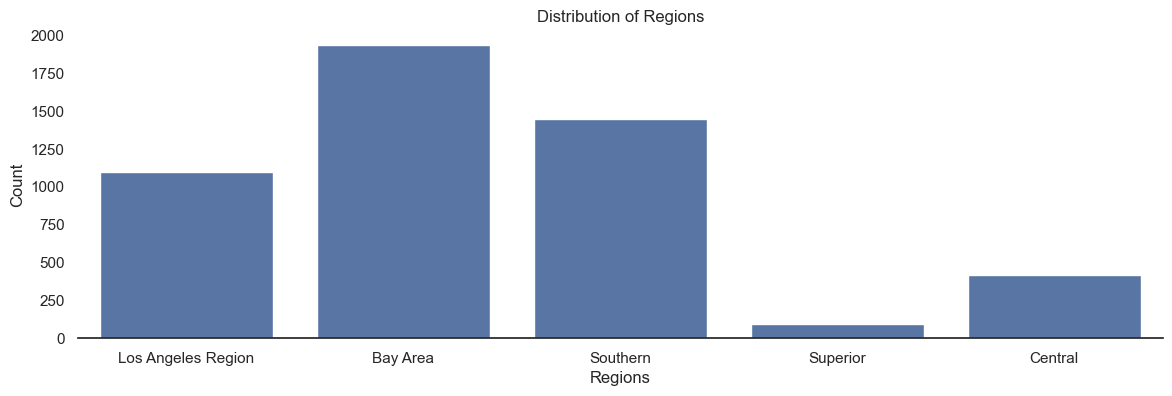

In [7907]:
ax = sns.countplot(data=data, x="Regions")
sns.despine(top=True, right=True, left=True)

plt.title("Distribution of Regions")
plt.xlabel("Regions")
plt.ylabel("Count")
plt.show()

### 6.5 Bivariate Analysis: Categorical Features vs Personal Loan (Stacked Bar Plots)
This step visualizes the relationship between selected categorical features and the target variable `PersonalLoan` using stacked bar plots. It helps identify patterns and differences in personal loan uptake across categories.


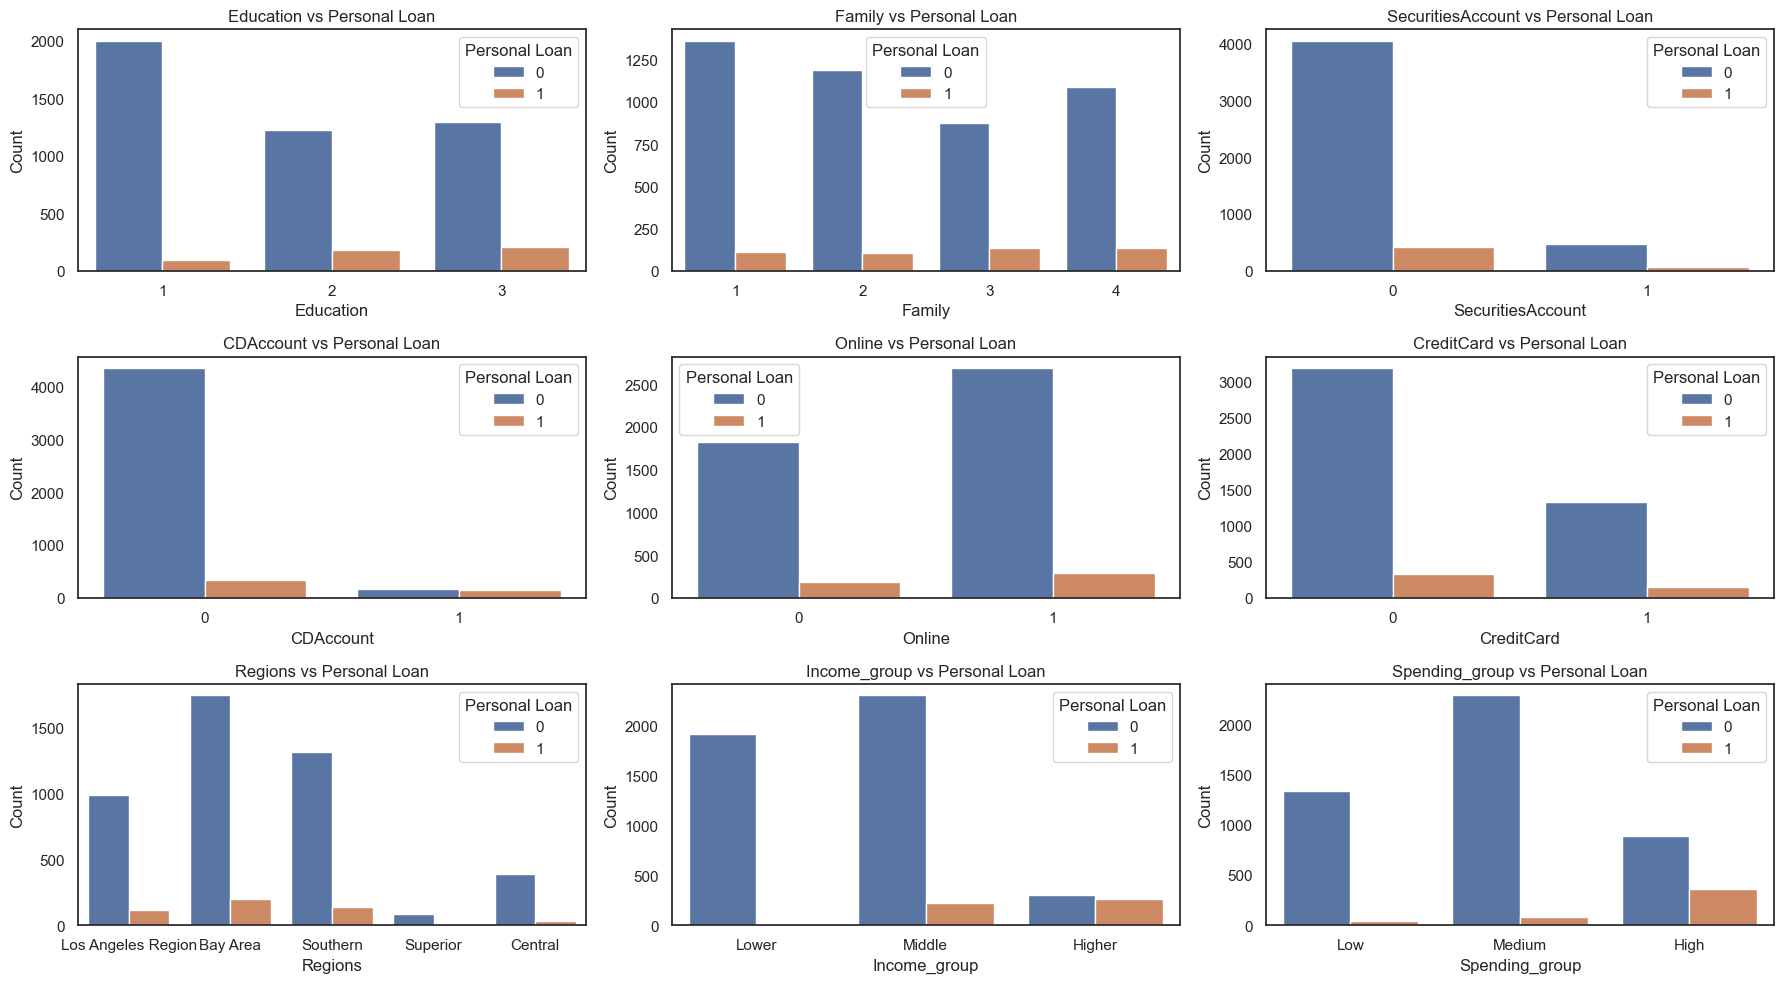

In [ ]:

# List of categorical columns to analyze
cat_cols = [
    'Education', 'Family', 'SecuritiesAccount', 'CDAccount',
    'Online', 'CreditCard', 'Regions', 'Income_group', 'Spending_group'
]

plt.figure(figsize=(18, 10))

# Loop through each categorical column to create count plots grouped by PersonalLoan
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1)   # 3x3 grid for 9 plots
    
    sns.countplot(
        x=col,
        data=data,
        hue='PersonalLoan'
    )
    
    plt.title(f'{col} vs Personal Loan')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Personal Loan')

plt.tight_layout()
plt.show()


### 6.6 Bivariate Analysis: Numeric Features vs Personal Loan (Histograms with KDE)
This step visualizes the distribution of numeric features (`Age`, `Experience`, `Income`, `CCAvg`, `Mortgage`) grouped by `PersonalLoan` status using histograms with KDE. It helps compare density patterns between customers who did and did not take a personal loan.


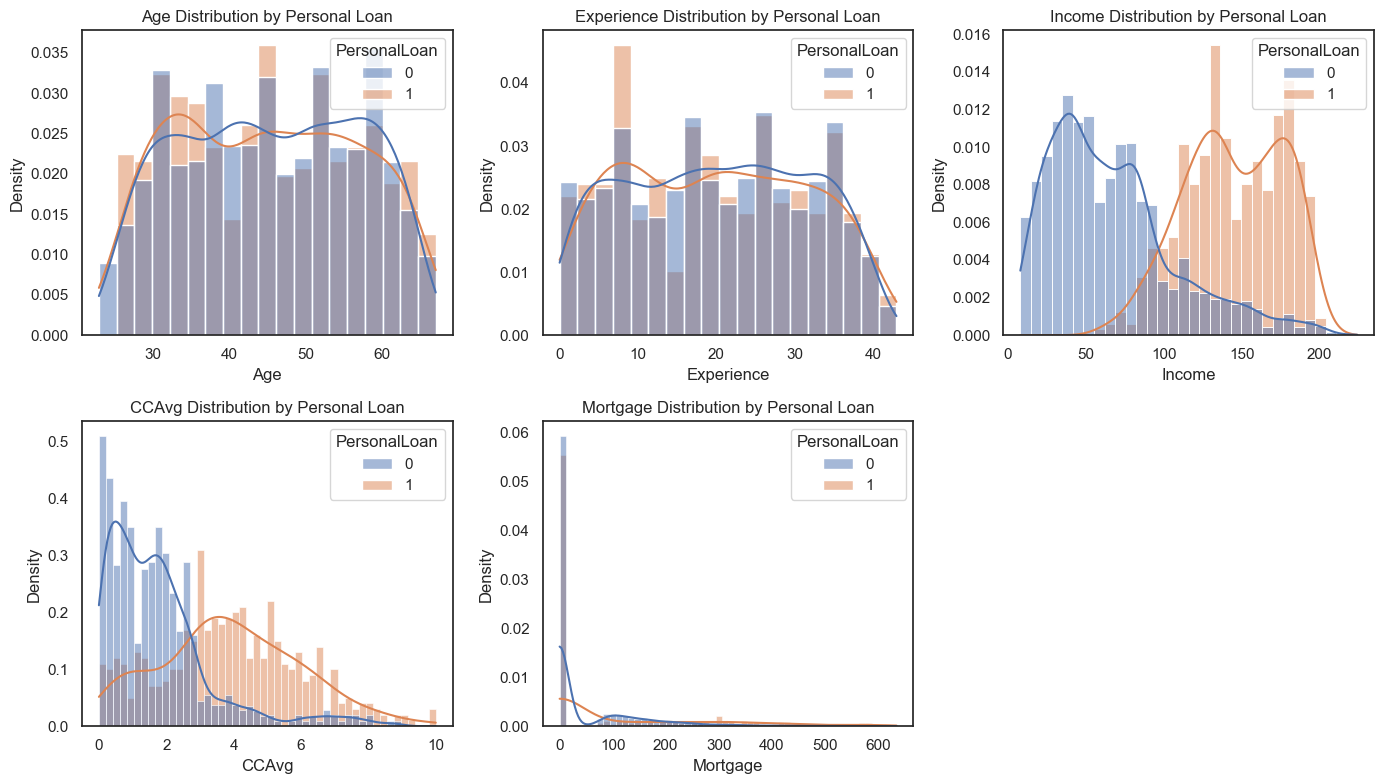

In [7909]:
# List of numeric columns to analyze
numeric_columns = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

plt.figure(figsize=(14, 8))

# Loop through each numeric column to create histograms grouped by PersonalLoan
for i, variable in enumerate(numeric_columns):
    plt.subplot(2, 3, i + 1)
    
    # Histogram with KDE for each PersonalLoan group
    sns.histplot(
        data=data,
        x=variable,
        hue='PersonalLoan',
        kde=True,
        stat='density',
        common_norm=False
    )
    plt.title(f'{variable} Distribution by Personal Loan')
    plt.xlabel(variable)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()


### 6.7 Distribution of CCAvg by Personal Loan Status

This step visualizes the distribution of the `CCAvg` variable separately for customers who did and did not take a personal loan. A KDE plot helps compare density patterns and detect differences in spending behavior.

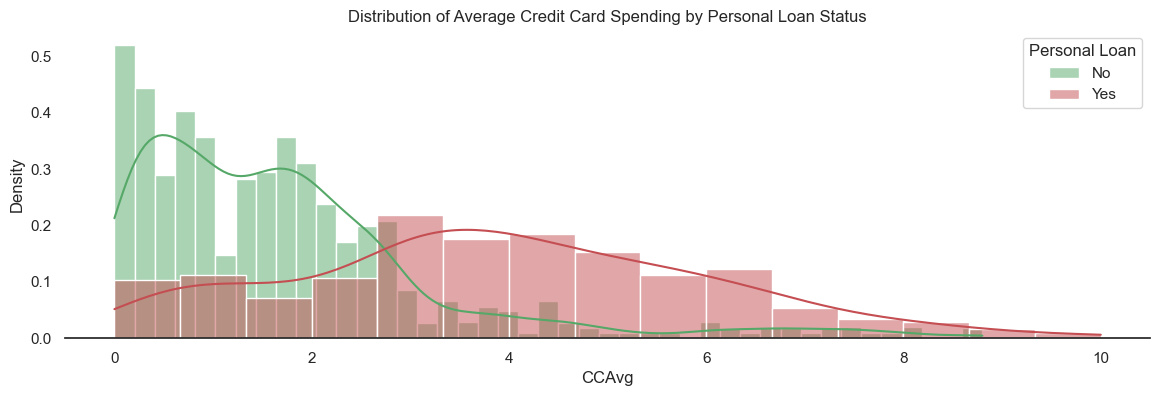

In [7910]:
# Function to plot CCAvg distribution for PersonalLoan groups
def plot_ccavg_distribution():
    plt.figure(figsize=(14, 4))
    
    # Customers who did not take a personal loan
    sns.histplot(
        data[data["PersonalLoan"] == 0]["CCAvg"],
        color="g",
        kde=True,
        stat="density",
        label="No"
    )
    
    # Customers who did take a personal loan
    sns.histplot(
        data[data["PersonalLoan"] == 1]["CCAvg"],
        color="r",
        kde=True,
        stat="density",
        label="Yes"
    )
    
    plt.title("Distribution of Average Credit Card Spending by Personal Loan Status")
    plt.xlabel("CCAvg")
    plt.ylabel("Density")
    plt.legend(title="Personal Loan")
    sns.despine(top=True, right=True, left=True)
    plt.show()

# Call the function
plot_ccavg_distribution()

### 6.8 County vs Personal Loan Uptake

This analysis compares personal loan uptake across the top 20 counties using percentage-based stacked bar charts.

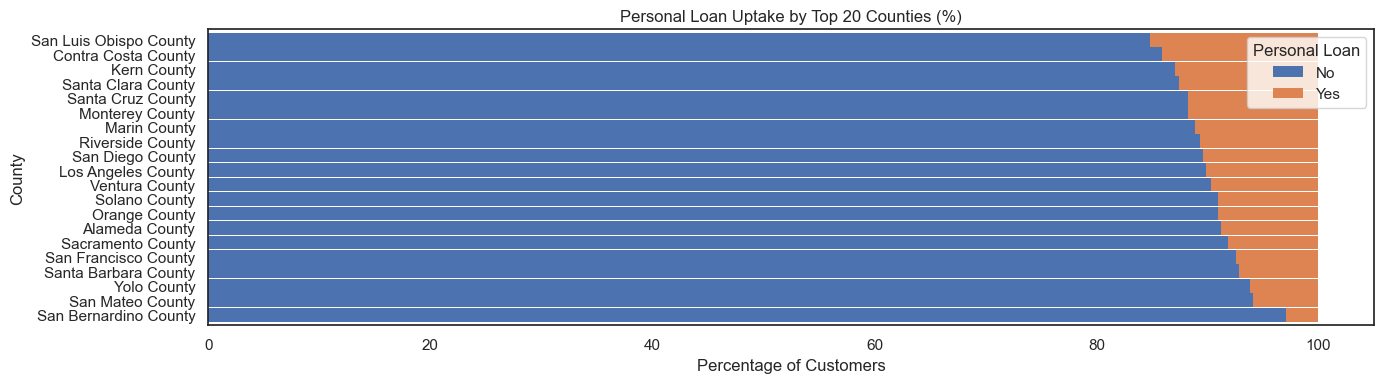

In [7911]:
top_counties = data["County"].value_counts().head(20).index
filtered_data = data[data["County"].isin(top_counties)]

county_loan_pct = pd.crosstab(
    filtered_data["County"],
    filtered_data["PersonalLoan"],
    normalize="index"
) * 100

county_loan_pct = county_loan_pct.sort_values(by=1, ascending=True)

ax = county_loan_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 4),
    width=0.95,
    edgecolor="none"
)

plt.title("Personal Loan Uptake by Top 20 Counties (%)")
plt.xlabel("Percentage of Customers")
plt.ylabel("County")
plt.legend(title="Personal Loan", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

### 6.9 Correlation Analysis: Numerical Features
This step calculates and visualizes the correlation matrix for numerical features to identify relationships and potential multicollinearity. A heatmap with annotations highlights the strength and direction of linear associations between variables.


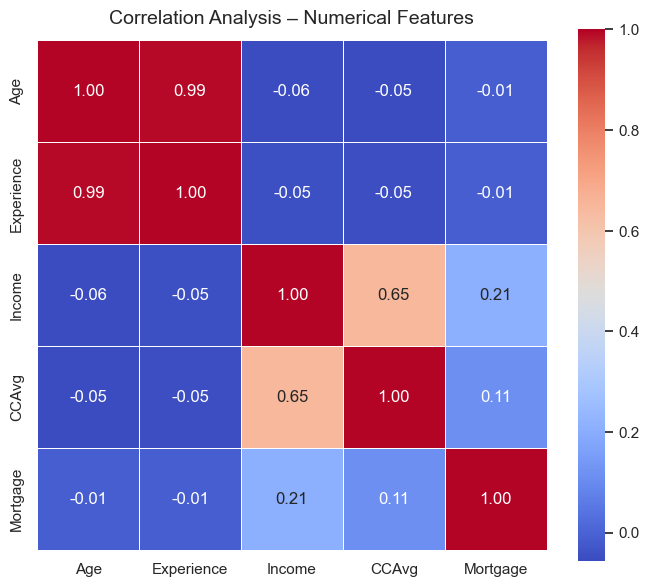

In [7912]:
# List of numeric columns to include in correlation analysis
numeric_columns = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# Compute correlation matrix
corr_matrix = data[numeric_columns].corr()

plt.figure(figsize=(7, 7))

# Plot heatmap of correlations
sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",         
    cmap='coolwarm',   
    linewidths=0.5,    
    square=True,       
    cbar_kws={"shrink": 0.8}  
)

plt.title('Correlation Analysis – Numerical Features', fontsize=14, pad=12)
plt.tight_layout()
plt.show()



### 6.10 EDA Summary and Dataset Readiness

This section summarises the main findings from the exploratory analysis and confirms that the dataset is ready for modelling.

**Key Insights:**
- Both numerical and categorical features show meaningful patterns related to personal loan uptake.
- Higher income, stronger credit card spending, and certain education and family profiles are associated with greater loan acceptance.
- Geographic differences suggest that location may also influence customer response behaviour.
- The target variable `PersonalLoan` is imbalanced, with most customers not accepting the loan offer.
- Engineered features such as `Agebin`, `Income_group`, `Spending_group`, and `Regions` were created to support analysis and modelling.

**Dataset Readiness Checks:**
- No missing values remain.
- Categorical variables have been converted into appropriate formats.
- Key numeric variables have been reviewed and cleaned, including invalid `Experience` values.
- The target variable is clearly defined as `PersonalLoan`.

Overall, the dataset is ready for the modelling stage.

## 7. Modelling

This section builds and evaluates classification models to predict whether a customer is likely to accept a personal loan offer.

### 7.1 Data Preparation for Modelling

The dataset is prepared for training and testing so model performance can be evaluated on unseen data.

#### 7.1.1 Drop Unnecessary Columns

Variables that are redundant, high-cardinality, or created mainly for exploratory analysis are removed to simplify the feature set and reduce multicollinearity.


In [7913]:
data.drop(
    columns=["Agebin", "ZIPCode", "County", "Experience", "Income_group", "Spending_group"],
    inplace=True
)

#### 7.1.2 Define Features and Target Variable

The dataset is split into input features `X` and the target variable `y`, where `PersonalLoan` represents whether a customer accepted the loan offer.



In [7914]:
X = data.drop(columns=["PersonalLoan"])  # Features
y = data["PersonalLoan"]                 # Target


#### 7.1.3 One-Hot Encoding for Categorical Features

One-hot encoding transforms categorical features into a numerical format while avoiding redundant columns by dropping the first category.

In [7915]:
oneHotCols = ["Regions", "Education"]

X = pd.get_dummies(
    X,
    columns=oneHotCols,
    drop_first=True,
    dtype="int8"
)


#### 7.1.4 Train-Test Split

The dataset is split into training and testing sets, with 70% used for training and 30% reserved for testing. Stratified sampling is applied to preserve the class distribution of the target variable.


In [7916]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=98,
    stratify=y
)


#### 7.1.5 Feature Scaling

The feature variables are standardised using `StandardScaler` so that all inputs are on a comparable scale.


In [ ]:
# Create scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


#### 7.1.6 Resetting Indexes
Reset indexes for training and testing sets to ensure alignment and prevent index-related errors during modeling.


In [ ]:
X_train_scaled_df.index = np.arange(len(X_train_scaled_df))
X_test_scaled_df.index = np.arange(len(X_test_scaled_df))
y_train.index = np.arange(len(y_train))
y_test.index = np.arange(len(y_test))

### 7.2 Confusion Matrix Visualisation Function

The following function displays a confusion matrix to compare actual and predicted personal loan outcomes. It helps evaluate how well a classification model identifies both loan acceptance and non-acceptance.

In [7919]:
# Function to display train and test confusion matrices side by side
def make_confusion_matrix(y_train_actual, y_train_predict,
                                         y_test_actual, y_test_predict,
                                         title1="Confusion Matrix for Train",
                                         title2="Confusion Matrix for Test"):
    
    cm_train = confusion_matrix(y_train_actual, y_train_predict, labels=[0, 1])
    cm_test = confusion_matrix(y_test_actual, y_test_predict, labels=[0, 1])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    disp_train = ConfusionMatrixDisplay(
        confusion_matrix=cm_train,
        display_labels=["No", "Yes"]
    )
    disp_train.plot(cmap="Greens", colorbar=False, ax=axes[0], values_format="d")
    axes[0].set_title(title1, fontsize=14)
    axes[0].tick_params(axis="both", which="both", length=0)
    axes[0].grid(False)
    
    disp_test = ConfusionMatrixDisplay(
        confusion_matrix=cm_test,
        display_labels=["No", "Yes"]
    )
    disp_test.plot(cmap="Greens", colorbar=False, ax=axes[1], values_format="d")
    axes[1].set_title(title2, fontsize=14)
    axes[1].tick_params(axis="both", which="both", length=0)
    axes[1].grid(False)
    
    plt.tight_layout()
    plt.show()

### 7.3 Model Evaluation Function

The following function evaluates classification performance on both training and test data using Accuracy, Recall, Precision, and F1-score. It also supports custom threshold-based predictions and optional ROC-AUC reporting with confusion matrix visualisation.


In [7920]:

def get_metrics_score(model, X_train_df, X_test_df, y_train_pass, y_test_pass, 
                      statsklearn, threshold=0.5, flag=True, roc=False):

    # List to store all evaluation metrics (train & test)
    score_list = []

    # Generate predictions
    # statsklearn = 0 → sklearn-style predict()
    # statsklearn = 1 → probability output with custom threshold
    if statsklearn == 0:
        pred_train = model.predict(X_train_df)
        pred_test = model.predict(X_test_df)
    else:
        pred_train = (model.predict(X_train_df) > threshold)
        pred_test = (model.predict(X_test_df) > threshold)

    # Convert predictions to binary values (0 or 1)
    pred_train = np.round(pred_train)
    pred_test = np.round(pred_test)

    # Calculate core classification metrics
    train_acc = accuracy_score(y_train_pass, pred_train)
    test_acc = accuracy_score(y_test_pass, pred_test)

    train_recall = recall_score(y_train_pass, pred_train)
    test_recall = recall_score(y_test_pass, pred_test)

    train_precision = precision_score(y_train_pass, pred_train)
    test_precision = precision_score(y_test_pass, pred_test)

    train_f1 = f1_score(y_train_pass, pred_train)
    test_f1 = f1_score(y_test_pass, pred_test)

    # Store metrics in a structured list for comparison or reporting
    score_list.extend((
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ))

 
        
    # Display metrics and confusion matrices if flag is enabled
    if flag:
        print("\x1b[0;30;47m \033[1mMODEL PERFORMANCE\x1b[0m")

        print("\x1b[0;30;47m \033[1mAccuracy   : Train:\x1b[0m",
              round(train_acc, 3),
              "\x1b[0;30;47m \033[1mTest:\x1b[0m ",
              round(test_acc, 3))

        print("\x1b[0;30;47m \033[1mRecall     : Train:\x1b[0m",
              round(train_recall, 3),
              "\x1b[0;30;47m \033[1mTest:\x1b[0m",
              round(test_recall, 3))

        print("\x1b[0;30;47m \033[1mPrecision  : Train:\x1b[0m",
              round(train_precision, 3),
              "\x1b[0;30;47m \033[1mTest:\x1b[0m ",
              round(test_precision, 3))

        print("\x1b[0;30;47m \033[1mF1         : Train:\x1b[0m",
              round(train_f1, 3),
              "\x1b[0;30;47m \033[1mTest:\x1b[0m",
              round(test_f1, 3))
        
    # Compute ROC-AUC score
    if roc:
        print("\x1b[0;30;47m \033[1mROC-AUC Score  : Train:\x1b[0m",
              round(roc_auc_score(y_train_pass, pred_train), 3),
              "\x1b[0;30;47m \033[1mTest:\x1b[0m",
              round(roc_auc_score(y_test_pass, pred_test), 3))

        # Visualize confusion matrices
        make_confusion_matrix(y_train_pass, pred_train, y_test_pass, pred_test)

    # Return evaluation metrics for further comparison across models
    return score_list


### 7.4 Store Model Performance Metrics

The following lists and helper function are used to store training and testing metrics for each model, making it easier to compare performance consistently across multiple classification approaches.

In [7921]:
# Lists to store model performance metrics
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []
f1_train = []
f1_test = []

# Function to add model scores to the lists
def add_score_model(score):
    acc_train.append(score[0])
    acc_test.append(score[1])
    recall_train.append(score[2])
    recall_test.append(score[3])
    precision_train.append(score[4])
    precision_test.append(score[5])
    f1_train.append(score[6])
    f1_test.append(score[7])

### 7.5 Baseline Model - Logistic Regression (Scikit-learn)

A logistic regression model is trained on the scaled features to predict personal loan acceptance. Class weights are applied to better handle the imbalanced target, and performance is evaluated on both training and test data.

 MODEL PERFORMANCE
 Accuracy   : Train: 0.658  Test:  0.672
 Recall     : Train: 0.985  Test: 0.979
 Precision  : Train: 0.217  Test:  0.224
 F1         : Train: 0.356  Test: 0.364
 ROC-AUC Score  : Train: 0.804  Test: 0.809


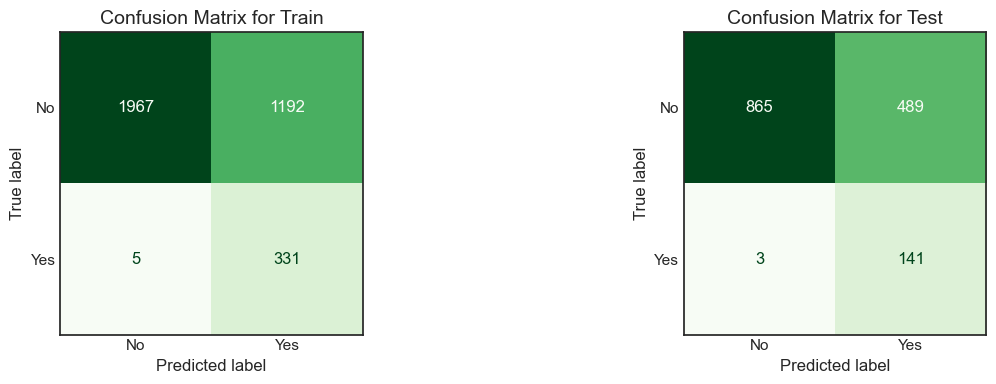

In [7922]:
# Logistic Regression model
lr = LogisticRegression(
    solver="newton-cg",
    random_state=1,
    fit_intercept=False,
    class_weight={0: 0.15, 1: 0.85}
)

# Fit the model
model = lr.fit(X_train_scaled_df, y_train)

# 0 = sklearn predict()
statmodel = 0

# Evaluate model
scores_sklearn = get_metrics_score(
    model,
    X_train_scaled_df,
    X_test_scaled_df,
    y_train,
    y_test,
    statsklearn=statmodel,
    threshold=0.5,
    flag=True,
    roc=True
)

# Store metrics
add_score_model(scores_sklearn)

### 7.6 Interpretable Model - Logistic Regression (Statsmodels)

A logistic regression model is fitted using Statsmodels to provide statistical significance testing and coefficient interpretation. A constant term is added to include the intercept, and model performance is evaluated on both the training and test sets.

In [ ]:

# Add constant term to include intercept
X_train_stat = sm.add_constant(X_train_scaled_df)
X_test_stat = sm.add_constant(X_test_scaled_df)

# Specify prediction type: 0 = sklearn, 1 = statsmodels
statmodel = 1

# Initialize and fit Logistic Regression using Statsmodels
logit = sm.Logit(y_train, X_train_stat.astype(float))
lg = logit.fit(warn_convergence=False)

# Evaluate model performance
scores_statmodel = get_metrics_score(
    lg,
    X_train_stat,
    X_test_stat,
    y_train,
    y_test,
    statsklearn=statmodel
)

# Display the summary of the Statsmodels Logistic Regression model
lg.summary()


Optimization terminated successfully.
         Current function value: 0.120817
         Iterations 9
 MODEL PERFORMANCE
 Accuracy   : Train: 0.959  Test:  0.955
 Recall     : Train: 0.655  Test: 0.688
 Precision  : Train: 0.887  Test:  0.818
 F1         : Train: 0.753  Test: 0.747


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           PersonalLoan   No. Observations:                 3495
Model:                          Logit   Df Residuals:                     3479
Method:                           MLE   Df Model:                           15
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                  0.6183
Time:                        18:40:02   Log-Likelihood:                -422.26
converged:                       True   LL-Null:                       -1106.2
Covariance Type:            nonrobust   LLR p-value:                1.326e-282
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -4.9120      0.208    -23.647      0.000      -5.319      -4.505
Age                            0.1544      0.092      1.677      0.093      -0.026       0.335
Income                         2.7703      0.161     17.255      0.000       2.456       3.085
Family                         0.7355      0.106      6.915      0.000       0.527       0.944
CCAvg                          0.2245      0.092      2.438      0.015       0.044       0.405
Mortgage                       0.0263      0.072      0.366      0.714      -0.115       0.167
SecuritiesAccount             -0.3118      0.111     -2.812      0.005      -0.529      -0.095
CDAccount                      0.9398      0.098      9.592      0.000       0.748       1.132
Online                        -0.3909      0.097     -4.043      0.000      -0.580      -0.201
CreditCard                    -0.4309      0.112     -3.836      0.000      -0.651      -0.211
Regions_Central               -0.1480      0.106     -1.395      0.163      -0.356       0.060
Regions_Los Angeles Region     0.0135      0.100      0.135      0.893      -0.183       0.210
Regions_Southern               0.0802      0.102      0.789      0.430      -0.119       0.279
Regions_Superior               0.0593      0.118      0.501      0.617      -0.173       0.291
Education_2                    1.6836      0.140     12.006      0.000       1.409       1.958
Education_3                    1.7457      0.139     12.536      0.000       1.473       2.019
==============================================================================================
"""

#### 7.6.1 Coefficient Summary

This table summarises the fitted Statsmodels logistic regression results, including coefficients, odds ratios, confidence intervals, and statistical significance. It helps identify which features meaningfully influence personal loan acceptance.

- **Feature**: Predictor name  
- **Coefficient**: Estimated regression coefficient  
- **Odds Ratio**: Exponentiated coefficient showing effect on odds  
- **Std Error, z-value, p-value**: Statistical significance measures  
- **CI_Lower / CI_Upper**: 95% confidence interval for the odds ratio  
- **Significance**: Significance level indicator

In [7924]:
# Create readable coefficient summary table
summary_df = pd.DataFrame({
    "Feature": lg.params.index,
    "Coefficient": lg.params.values,
    "Odds_Ratio": np.exp(lg.params.values),
    "Std_Error": lg.bse.values,
    "z_value": lg.tvalues.values,
    "p_value": lg.pvalues.values,
    "CI_Lower": np.exp(lg.conf_int()[0]),
    "CI_Upper": np.exp(lg.conf_int()[1])
})

# Add significance labels
summary_df["Significance"] = np.where(
    summary_df["p_value"] < 0.01, "***",
    np.where(summary_df["p_value"] < 0.05, "**",
             np.where(summary_df["p_value"] < 0.1, "*", "Not Significant"))
)

# Sort by p-value
summary_df = summary_df.sort_values("p_value").reset_index(drop=True)

summary_df

,Feature,Coefficient,Odds_Ratio,Std_Error,z_value,p_value,CI_Lower,CI_Upper,Significance
0,const,-4.91,0.01,0.21,-23.65,0.00,0.00,0.01,***
1,Income,2.77,15.96,0.16,17.25,0.00,11.65,21.87,***
2,Education_3,1.75,5.73,0.14,12.54,0.00,4.36,7.53,***
3,Education_2,1.68,5.39,0.14,12.01,0.00,4.09,7.09,***
4,CDAccount,0.94,2.56,0.10,9.59,0.00,2.11,3.10,***
5,Family,0.74,2.09,0.11,6.92,0.00,1.69,2.57,***
6,Online,-0.39,0.68,0.10,-4.04,0.00,0.56,0.82,***
7,CreditCard,-0.43,0.65,0.11,-3.84,0.00,0.52,0.81,***
8,SecuritiesAccount,-0.31,0.73,0.11,-2.81,0.00,0.59,0.91,***
9,CCAvg,0.22,1.25,0.09,2.44,0.01,1.04,1.50,**


> **Interpretation:**  The results suggest that `Income`, `Education`, `CDAccount`, `Family`, and `CCAvg` are the strongest positive predictors of personal loan acceptance, while `Online`, `CreditCard`, and `SecuritiesAccount` are associated with lower odds. The regional variables are not statistically significant, indicating that `Regions` adds limited value to the model and will be removed.

#### 7.6.2 Refined Logistic Regression Model

Non-significant variables are removed to simplify the model and retain only the most meaningful predictors of personal loan acceptance.

In [7925]:
X_train1 = X_train_stat.drop(
    ['Regions_Central', 'Regions_Los Angeles Region', 'Regions_Southern',
     'Regions_Superior', 'Age', 'Mortgage'],
    axis=1
)

X_test1 = X_test_stat.drop(
    ['Regions_Central', 'Regions_Los Angeles Region', 'Regions_Southern',
     'Regions_Superior', 'Age', 'Mortgage'],
    axis=1
)

logit1 = sm.Logit(y_train, X_train1.astype(float))
lg1 = logit1.fit(warn_convergence=False)

lg1.summary()

Optimization terminated successfully.
         Current function value: 0.121782
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           PersonalLoan   No. Observations:                 3495
Model:                          Logit   Df Residuals:                     3485
Method:                           MLE   Df Model:                            9
Date:                Fri, 27 Mar 2026   Pseudo R-squ.:                  0.6152
Time:                        18:40:02   Log-Likelihood:                -425.63
converged:                       True   LL-Null:                       -1106.2
Covariance Type:            nonrobust   LLR p-value:                1.898e-287
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -4.8836      0.206    -23.747      0.000      -5.287      -4.481
Income                2.7473      0.157     17.479      0.000       2.439       3.055
Family                0.7274      0.106      6.876      0.000       0.520       0.935
CCAvg                 0.2153      0.091      2.379      0.017       0.038       0.393
SecuritiesAccount    -0.3040      0.110     -2.761      0.006      -0.520      -0.088
CDAccount             0.9395      0.097      9.671      0.000       0.749       1.130
Online               -0.3866      0.096     -4.028      0.000      -0.575      -0.198
CreditCard           -0.4371      0.112     -3.900      0.000      -0.657      -0.217
Education_2           1.6816      0.139     12.105      0.000       1.409       1.954
Education_3           1.7389      0.138     12.599      0.000       1.468       2.009
=====================================================================================
"""

**Interpretation:**  The refined logistic regression model retains only statistically significant predictors and still explains a substantial share of the variation in personal loan acceptance. `Income`, `Education`, `CDAccount`, `Family`, and `CCAvg` remain strong positive predictors, while `Online`, `CreditCard`, and `SecuritiesAccount` are associated with lower odds of loan uptake. The strong model significance and improved simplicity suggest that the reduced feature set is both interpretable and effective for prediction.

#### 7.6.3 Refined Model Coefficient Summary

This table summarises the coefficients, odds ratios, confidence intervals, and statistical significance of the refined logistic regression model.

In [7926]:
# Create readable coefficient summary table
summary_df = pd.DataFrame({
    "Feature": lg1.params.index,
    "Coefficient": lg1.params.values,
    "Odds_Ratio": np.exp(lg1.params.values),
    "Std_Error": lg1.bse.values,
    "z_value": lg1.tvalues.values,
    "p_value": lg1.pvalues.values,
    "CI_Lower": np.exp(lg1.conf_int()[0]),
    "CI_Upper": np.exp(lg1.conf_int()[1])
})

# Add significance labels
summary_df["Significance"] = np.where(
    summary_df["p_value"] < 0.01, "***",
    np.where(summary_df["p_value"] < 0.05, "**",
             np.where(summary_df["p_value"] < 0.1, "*", "Not Significant"))
)

# Sort by p-value
summary_df = summary_df.sort_values("p_value").reset_index(drop=True)

summary_df

,Feature,Coefficient,Odds_Ratio,Std_Error,z_value,p_value,CI_Lower,CI_Upper,Significance
0,const,-4.88,0.01,0.21,-23.75,0.00,0.01,0.01,***
1,Income,2.75,15.60,0.16,17.48,0.00,11.46,21.23,***
2,Education_3,1.74,5.69,0.14,12.60,0.00,4.34,7.46,***
3,Education_2,1.68,5.37,0.14,12.11,0.00,4.09,7.06,***
4,CDAccount,0.94,2.56,0.10,9.67,0.00,2.12,3.10,***
5,Family,0.73,2.07,0.11,6.88,0.00,1.68,2.55,***
6,Online,-0.39,0.68,0.10,-4.03,0.00,0.56,0.82,***
7,CreditCard,-0.44,0.65,0.11,-3.90,0.00,0.52,0.80,***
8,SecuritiesAccount,-0.30,0.74,0.11,-2.76,0.01,0.59,0.92,***
9,CCAvg,0.22,1.24,0.09,2.38,0.02,1.04,1.48,**


> **Interpretation:**  The refined coefficient summary confirms that the retained features are statistically meaningful predictors of personal loan acceptance. Positive coefficients increase the likelihood of loan uptake, while negative coefficients reduce it, making the table useful for both interpretation and model simplification.

#### 7.6.4 Refined Model Performance

The refined logistic regression model is evaluated on the training and test sets using standard classification metrics, and the results are stored for comparison with other models.

In [7927]:
# Evaluate refined logistic regression model
scores_statmodel = get_metrics_score(
    lg1,
    X_train1,
    X_test1,
    y_train,
    y_test,
    statmodel
)

# Store metrics for comparison
add_score_model(scores_statmodel)

 MODEL PERFORMANCE
 Accuracy   : Train: 0.959  Test:  0.957
 Recall     : Train: 0.664  Test: 0.701
 Precision  : Train: 0.881  Test:  0.828
 F1         : Train: 0.757  Test: 0.759


> **Interpretation:**  These results show how well the refined model performs after removing non-significant features, helping assess whether model simplification improves practical performance.

#### 7.6.5 Coefficient and Odds Ratio Interpretation

This section interprets the refined logistic regression results using odds ratios and percentage change in odds, making the effect of each predictor easier to understand.

**Odds Table Summary**
- **Coefficient**: Log-odds effect of each predictor.
- **Odds Ratio**: Direction and strength of impact on loan acceptance (`> 1` increases odds, `< 1` decreases odds).
- **Probability**: Converts odds into an approximate probability.
- **Percentage Change in Odds**: Change in odds for a one-unit increase in the predictor.
- **p-value**: Indicates statistical significance.

In [7928]:
# Create DataFrame for coefficients
lgcoef = pd.DataFrame(lg1.params, columns=["Coefficient"])

# Calculate odds ratio
lgcoef["Odds_Ratio"] = np.exp(lgcoef["Coefficient"])

# Convert odds ratio to probability
lgcoef["Probability"] = lgcoef["Odds_Ratio"] / (1 + lgcoef["Odds_Ratio"])

# Calculate percentage change in odds
lgcoef["Percentage_Change_Odds"] = (lgcoef["Odds_Ratio"] - 1) * 100

# Include p-values for significance
lgcoef["p_value"] = lg1.pvalues

# Format for readability
pd.options.display.float_format = "{:.2f}".format

# Sort by odds ratio
lgcoef = lgcoef.sort_values(by="Odds_Ratio", ascending=False)

lgcoef

,Coefficient,Odds_Ratio,Probability,Percentage_Change_Odds,p_value
Income,2.75,15.60,0.94,1460.11,0.00
Education_3,1.74,5.69,0.85,469.09,0.00
Education_2,1.68,5.37,0.84,437.43,0.00
CDAccount,0.94,2.56,0.72,155.87,0.00
Family,0.73,2.07,0.67,106.98,0.00
CCAvg,0.22,1.24,0.55,24.02,0.02
SecuritiesAccount,-0.30,0.74,0.42,-26.22,0.01
Online,-0.39,0.68,0.40,-32.06,0.00
CreditCard,-0.44,0.65,0.39,-35.41,0.00
const,-4.88,0.01,0.01,-99.24,0.00


> **Interpretation:**  
Features with positive coefficients and odds ratios above 1 increase the likelihood of personal loan acceptance, while features with negative coefficients and odds ratios below 1 reduce it. This table helps translate the model results into a more interpretable business view by showing the direction, strength, and statistical significance of each predictor.

### 7.7 Logistic Regression with ROC-Optimal Threshold

This model applies a threshold selected from the ROC curve to improve the balance between true positive rate and false positive rate.

#### 7.7.1 ROC Curve Evaluation

The ROC curve assesses how well the model distinguishes between customers who accept and do not accept a personal loan across different classification thresholds.

- **True Positive Rate (TPR):** Proportion of actual positive cases correctly identified.  
- **False Positive Rate (FPR):** Proportion of actual negative cases incorrectly classified as positive.  
- **AUC (Area Under the Curve):** Overall measure of model discrimination, where values closer to 1 indicate stronger performance.

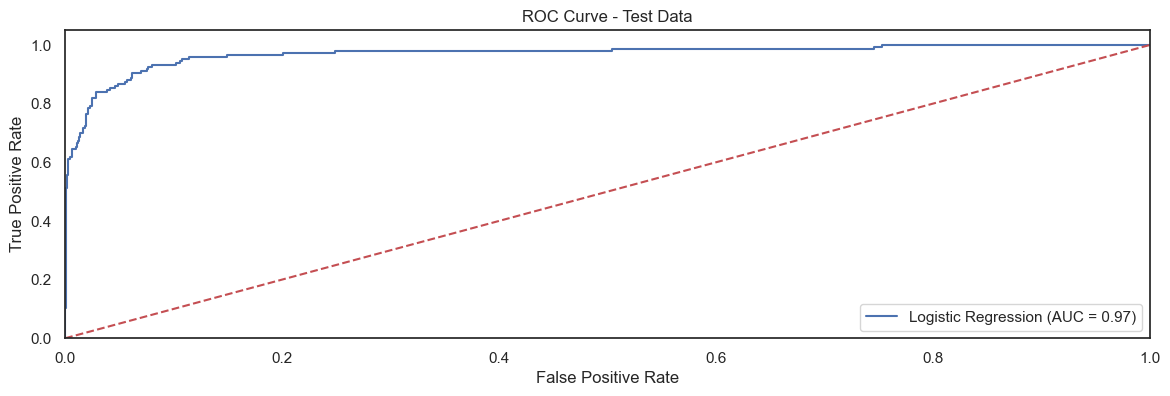

In [7929]:
# Predicted probabilities for the positive class
y_prob_test = lg1.predict(X_test1)

# Calculate ROC-AUC score
logit_roc_auc_test = roc_auc_score(y_test, y_prob_test)

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

# Plot ROC curve
plt.figure(figsize=(14, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {logit_roc_auc_test:.2f})")
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend(loc="lower right")
plt.show()


#### 7.7.2 ROC-Optimal Threshold Performance

The model is then evaluated using the threshold selected from the ROC curve.

Optimal Threshold: 0.12800301842286105
 MODEL PERFORMANCE
 Accuracy   : Train: 0.914  Test:  0.92
 Recall     : Train: 0.872  Test: 0.924
 Precision  : Train: 0.533  Test:  0.55
 F1         : Train: 0.661  Test: 0.689
 ROC-AUC Score  : Train: 0.895  Test: 0.922


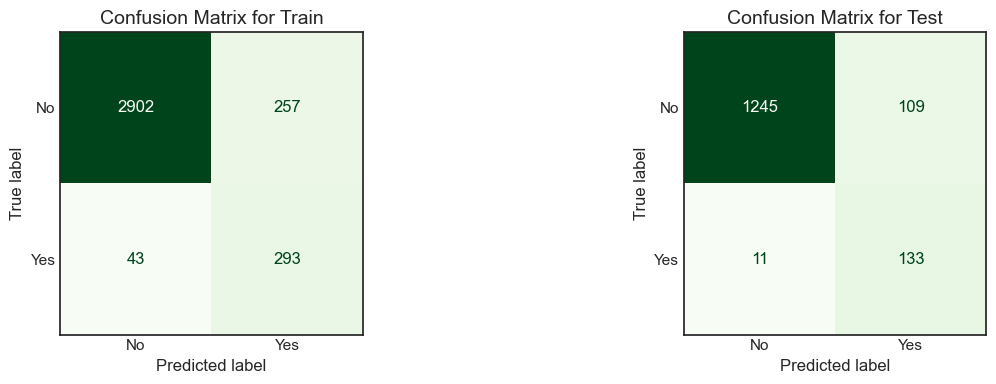

In [7930]:
# Identify the optimal threshold from the ROC curve
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print("Optimal Threshold:", optimal_threshold_auc_roc)

# Evaluate the model using the ROC-optimal threshold
scores_roc_threshold = get_metrics_score(
    lg1,
    X_train1,
    X_test1,
    y_train,
    y_test,
    statmodel,
    threshold=optimal_threshold_auc_roc,
    roc=True
)

# Store model scores
add_score_model(scores_roc_threshold)

> **Interpretation:**  
Using the ROC optimal threshold adjusts the decision boundary to better balance sensitivity and false positives, which can improve classification performance compared with the default threshold of 0.5.

### 7.8 Logistic Regression with Precision-Recall Threshold

This model uses a threshold selected from the precision-recall curve to improve recall while maintaining a reasonable level of precision, which is especially useful for imbalanced classification problems.

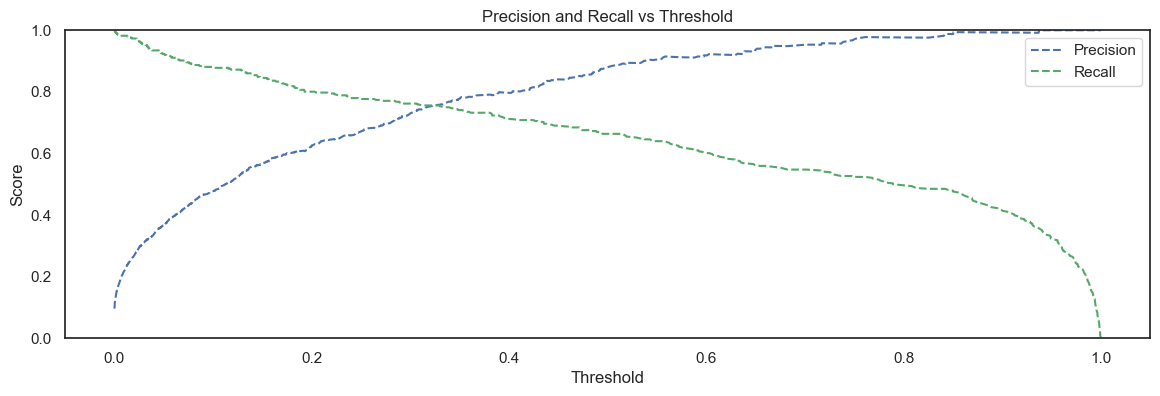

In [7931]:
# Predict probabilities on the training set
y_scores = lg1.predict(X_train1)

# Compute precision, recall, and thresholds
prec, rec, tre = precision_recall_curve(y_train, y_scores)

# Function to plot precision and recall against thresholds
def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.figure(figsize=(14, 4))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision and Recall vs Threshold")
    plt.legend(loc="upper right")
    plt.ylim([0, 1])

# Plot the precision-recall threshold curve
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

# Selected threshold based on the precision-recall curve
optimal_threshold_curve = 0.3

#### 7.8.1 Precision-Recall Threshold Performance

The model is evaluated using the threshold selected from the precision-recall curve.

 MODEL PERFORMANCE
 Accuracy   : Train: 0.95  Test:  0.958
 Recall     : Train: 0.762  Test: 0.819
 Precision  : Train: 0.731  Test:  0.761
 F1         : Train: 0.746  Test: 0.789
 ROC-AUC Score  : Train: 0.866  Test: 0.896


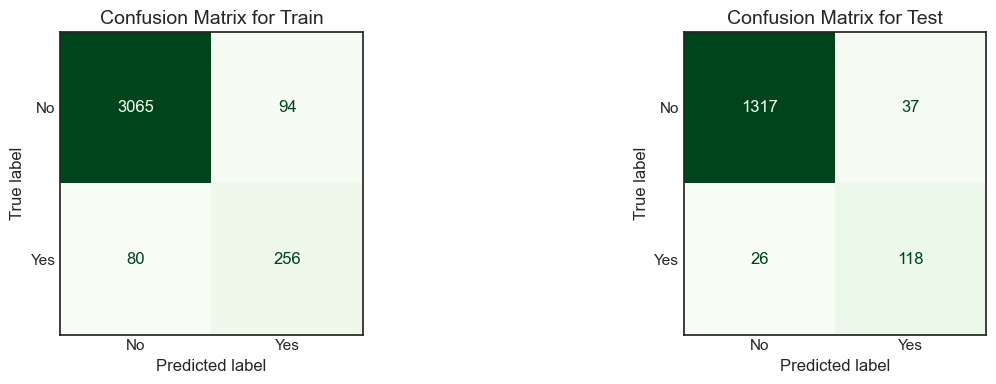

In [7932]:
# Evaluate model using the selected threshold
scores_opt_curve = get_metrics_score(
    lg1,
    X_train1,
    X_test1,
    y_train,
    y_test,
    statmodel,
    threshold=optimal_threshold_curve,
    roc=True
)

# Store model scores
add_score_model(scores_opt_curve)

> **Interpretation:**  Using a lower threshold from the precision-recall curve increases the model’s ability to identify likely loan accepters, which improves recall. This can be beneficial when missing potential responders is more costly than contacting some additional non-responders.

### 7.9 Logistic Regression with Sequential Feature Selection

This model uses forward sequential feature selection with logistic regression to identify the most informative predictors while maximising recall. 

Two reduced feature sets are evaluated to simplify the model while maintaining strong predictive performance.

    - Top 16 features selected using step-forward feature selection to maximize recall.
    - Top 11 features selected using step-forward feature selection to maximize recall.
    
This approach reduces model complexity while maintaining strong predictive performance.

#### 7.9.1 Top 16 Features Selected

Step-forward feature selection is used to identify the 16 most informative predictors for maximising recall.

In [7933]:
# Use training and testing sets from previous statsmodels preprocessing
X_train_seq = X_train_stat
X_test_seq = X_test_stat

# Model type: 0 = sklearn, 1 = statsmodels
statmodel = 0

# Define logistic regression model
clf = LogisticRegression(
    solver="newton-cg",
    random_state=1,
    fit_intercept=False
)

# Step-forward feature selection
sfs1 = sfs(
    clf,
    k_features=16,
    forward=True,
    floating=False,
    scoring="recall",
    verbose=2,
    cv=5
)

# Fit the sequential feature selector
sfs1 = sfs1.fit(X_train_seq, y_train)


[2026-03-27 18:40:04] Features: 1/16 -- score: 0.9910886742756805
[2026-03-27 18:40:05] Features: 2/16 -- score: 0.9940298507462686
[2026-03-27 18:40:06] Features: 3/16 -- score: 0.9940737489025461
[2026-03-27 18:40:07] Features: 4/16 -- score: 0.9940737489025461
[2026-03-27 18:40:08] Features: 5/16 -- score: 0.9940737489025461


[2026-03-27 18:40:08] Features: 6/16 -- score: 0.9940737489025461
[2026-03-27 18:40:09] Features: 7/16 -- score: 0.9940737489025461
[2026-03-27 18:40:09] Features: 8/16 -- score: 0.9940737489025461
[2026-03-27 18:40:09] Features: 9/16 -- score: 0.9910886742756804
[2026-03-27 18:40:09] Features: 10/16 -- score: 0.9910886742756804
[2026-03-27 18:40:09] Features: 11/16 -- score: 0.9910886742756804
[2026-03-27 18:40:10] Features: 12/16 -- score: 0.9910886742756804
[2026-03-27 18:40:10] Features: 13/16 -- score: 0.991044776119403
[2026-03-27 18:40:10] Features: 14/16 -- score: 0.9851185250219491
[2026-03-27 18:40:10] Features: 15/16 -- score: 0.982089552238806
[2026-03-27 18:40:10] Features: 16/16 -- score: 0.6546971027216857

> **Interpretation:**  This step selects the 16 predictors that contribute most to recall, helping reduce the feature set while preserving the model’s ability to identify likely loan accepters.

#### 7.9.2 Top 11 Features Selected

Step-forward feature selection is used to identify the 11 most informative predictors for maximising recall.

In [7934]:
# Model type: 0 = sklearn, 1 = statsmodels
statmodel = 0

clf = LogisticRegression(solver="newton-cg", random_state=1, fit_intercept=False)

# Step-forward feature selection
sfs1 = sfs(
    clf,
    k_features=11,
    forward=True,
    floating=False,
    scoring="recall",
    verbose=2,
    cv=5
)

# Fit sequential feature selector
sfs1 = sfs1.fit(X_train_seq, y_train)


[2026-03-27 18:40:11] Features: 1/11 -- score: 0.9910886742756805


[2026-03-27 18:40:11] Features: 2/11 -- score: 0.9940298507462686
[2026-03-27 18:40:12] Features: 3/11 -- score: 0.9940737489025461
[2026-03-27 18:40:12] Features: 4/11 -- score: 0.9940737489025461
[2026-03-27 18:40:13] Features: 5/11 -- score: 0.9940737489025461
[2026-03-27 18:40:13] Features: 6/11 -- score: 0.9940737489025461
[2026-03-27 18:40:13] Features: 7/11 -- score: 0.9940737489025461
[2026-03-27 18:40:13] Features: 8/11 -- score: 0.9940737489025461
[2026-03-27 18:40:14] Features: 9/11 -- score: 0.9910886742756804
[2026-03-27 18:40:14] Features: 10/11 -- score: 0.9910886742756804
[2026-03-27 18:40:14] Features: 11/11 -- score: 0.9910886742756804

> **Interpretation:**  This step selects a smaller subset of 11 predictors to further simplify the model while preserving recall-focused performance.

#### 7.9.3 Selected Features

This step displays the feature indices and names selected by sequential forward selection.

In [7935]:
# Get the indices of the selected features
feat_cols = list(sfs1.k_feature_idx_)

# Print selected feature indices
print(feat_cols)

# Display selected feature names
X_train_seq.columns[feat_cols]

[1, 2, 4, 5, 6, 8, 9, 10, 11, 13, 14]


Index(['Age', 'Income', 'CCAvg', 'Mortgage', 'SecuritiesAccount', 'Online',
       'CreditCard', 'Regions_Central', 'Regions_Los Angeles Region',
       'Regions_Superior', 'Education_2'],
      dtype='object')

> **Interpretation:**  These are the predictors identified as the most informative for maximising recall in the reduced logistic regression model.

#### 7.9.4 Logistic Regression with Selected Features

A logistic regression model is trained using only the features selected by sequential forward selection, and its performance is evaluated on the training and test sets.

In [7936]:
# Select only the features chosen by SFS
X_train_final = X_train_seq[X_train_seq.columns[feat_cols]]
X_test_final = X_test_seq[X_train_final.columns]

# Train logistic regression model
lr = LogisticRegression(solver="newton-cg", random_state=1, fit_intercept=False)
model = lr.fit(X_train_final, y_train)

# Model type: 0 = sklearn, 1 = statsmodels
statmodel = 0

# Evaluate model performance
scores_sfs = get_metrics_score(
    model,
    X_train_final,
    X_test_final,
    y_train,
    y_test,
    statmodel
)

# Store model scores
add_score_model(scores_sfs)

 MODEL PERFORMANCE
 Accuracy   : Train: 0.68  Test:  0.678
 Recall     : Train: 0.991  Test: 0.986
 Precision  : Train: 0.23  Test:  0.228
 F1         : Train: 0.373  Test: 0.37


> **Interpretation:**  This model tests whether a smaller, selected feature set can maintain strong predictive performance while improving simplicity and interpretability.

### 7.10 Model Performance Comparison

This section compares the performance of all evaluated models using training and test metrics to identify the most effective approach for personal loan prediction.

In [7937]:
comparison_frame = pd.DataFrame({
    "Models": [
        "Model 1 - Logistic Regression (Scikit-learn)",
        "Model 2 - Logistic Regression (Statsmodels)",
        "Model 3 - Logistic Regression (ROC-Optimal Threshold = 0.092)",
        "Model 4 - Logistic Regression (Precision-Recall Threshold = 0.30)",
        "Model 5 - Logistic Regression (Sequential Feature Selection)"
    ],
    "Train_Accuracy": acc_train,
    "Test_Accuracy": acc_test,
    "Train_Recall": recall_train,
    "Test_Recall": recall_test,
    "Train_Precision": precision_train,
    "Test_Precision": precision_test,
    "Train_F1": f1_train,
    "Test_F1": f1_test
})

best_idx = comparison_frame["Test_F1"].idxmax()

comparison_frame.style.apply(
    lambda row: ["background-color: #7DAA50; color: white;" if row.name == best_idx else "" for _ in row],
    axis=1
).format({
    "Train_Accuracy": "{:.2f}",
    "Test_Accuracy": "{:.2f}",
    "Train_Recall": "{:.2f}",
    "Test_Recall": "{:.2f}",
    "Train_Precision": "{:.2f}",
    "Test_Precision": "{:.2f}",
    "Train_F1": "{:.2f}",
    "Test_F1": "{:.2f}"
})

,Models,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1,Test_F1
0,Model 1 - Logistic Regression (Scikit-learn),0.66,0.67,0.99,0.98,0.22,0.22,0.36,0.36
1,Model 2 - Logistic Regression (Statsmodels),0.96,0.96,0.66,0.70,0.88,0.83,0.76,0.76
2,Model 3 - Logistic Regression (ROC-Optimal Threshold = 0.092),0.91,0.92,0.87,0.92,0.53,0.55,0.66,0.69
3,Model 4 - Logistic Regression (Precision-Recall Threshold = 0.30),0.95,0.96,0.76,0.82,0.73,0.76,0.75,0.79
4,Model 5 - Logistic Regression (Sequential Feature Selection),0.68,0.68,0.99,0.99,0.23,0.23,0.37,0.37


### 7.11 Model Performance Comparison

`Model 4` performs best overall, achieving the highest test F1-score and the strongest balance between recall and precision. `Models 1 and 5` achieve very high recall but at the cost of low precision, resulting in many false positives. `Model 2` is more conservative with lower recall, while `Model 3` improves recall through ROC-based threshold tuning but remains less balanced than `Model 4`.